# اعتبارسنجی و تخصیص خط اعتباری مشترکین دائمی تلکو

**هدف:** از دیتابیس مشترکین دائمی، آن دسته‌ای را پیدا کنیم که می‌توانند یک اعتبار خرد
(برای خرید خدمات تلکو) بگیرند و در **۴ قسط** روی صورتحساب ماهانه پس بدهند — و برای هرکس
بگوییم **چقدر**، با **چه ریسک نکولی** و **چه سود/زیان انتظاری**.

---

## تصمیم‌های طراحی (مهم‌ترین بخش؛ قبل از کد بخوانید)

### ۱) چرا فیلتر کردن با ARPU اشتباه است
میانگین درآمد شبکه ۱۳۰ هزار تومان است و فیلتر «ARPU بالاتر از میانگین» حدود ۶ میلیون نفر باقی می‌گذارد.
مشکل این است که **ARPU معیار ریسک نیست، معیار اندازه است**:

| مشترک | ARPU | سابقه | ریسک واقعی |
|---|---|---|---|
| الف | ۹۰ هزار | ۳۶ ماه، صفر قطعی، پرداخت روز سوم | **کم** |
| ب | ۳۰۰ هزار | ۱۴ ماه، ۳ قطعی، بدهی مزمن | **زیاد** |

فیلتر ARPU مشترک «ب» را قبول و «الف» را رد می‌کند — یعنی دقیقاً برعکس.
راه درست **تفکیک دو تصمیم** است:

> **«به کی بدهیم؟»** را ریسک تعیین می‌کند (مدل).
> **«چقدر بدهیم؟»** را ظرفیت پرداخت تعیین می‌کند (فرمول سقف).

نتیجهٔ عملی: جامعهٔ واجد شرایط به‌جای ۶ میلیون، به‌مراتب بزرگ‌تر می‌شود — چون مشترک کم‌مصرفِ
خوش‌حساب هم وارد می‌شود، فقط با سقف کوچک. و این برای محصولی که تیکتش خرد است اشکالی ندارد.

### ۲) لنگر سقف: «ظرفیت اثبات‌شدهٔ پرداخت» نه میانگین مصرف
اگر میانگین صورتحساب ۱۳۰ هزار باشد و ۵۰۰ هزار اعتبار بدهیم، قسط ماهانه ۱۳۰ هزار می‌شود و
صورتحساب پایان ماه **۲۶۰ هزار** — یعنی دو برابر چیزی که تاریخچه‌اش اثبات کرده می‌تواند بپردازد.
این «شوک صورتحساب» علت اصلی نکول در BNPL تلکو است، نه بدحسابی ذاتی.

پس لنگر را این می‌گذاریم:

$$P = \max\{\, \text{صورتحساب ماه } m \;:\; \text{ماه } m \text{ به‌موقع پرداخت شده} \,\}$$

و شرط توان پرداخت:

$$\underbrace{\text{قسط} + \mathbb{E}[\text{صورتحساب}]}_{\text{جریان خروجی ماهانهٔ جدید}} \;\le\; \alpha_g \times P$$

$$\boxed{\;L \;=\; \min\Big(\underbrace{\tfrac{n\,(\alpha_g P - \mathbb{E}[\text{bill}])}{1+f}}_{\text{توان پرداخت}},\;
\underbrace{m_g \times \mathbb{E}[\text{bill}]}_{\text{سقف نسبت به مصرف}},\;
\underbrace{h \cdot V_{sim}}_{\text{سقف وثیقه}},\;
\underbrace{C_g}_{\text{سقف مطلق رتبه}}\Big)\;}$$

که $n=4$ قسط، $f$ کارمزد کل، $g$ رتبهٔ ریسک. **خاصیت مهم:** هرچه مشترک صورتحساب بزرگ‌ترِ
شامل قسط را به‌موقع بپردازد، $P$ بالا می‌رود و سقف ماه بعد **خودکار** رشد می‌کند. نردبان رشد
بدون کمیته و بدون مدل جدید.

### ۳) تارگت آموزش: مسئلهٔ «شروع سرد» و راه‌حل جانشین
هنوز هیچ وامی نداده‌اید، پس **برچسب نکول واقعی وجود ندارد**. دو راه غلط و یک راه درست:

- ❌ آموزش روی «خوش‌حسابی» موجود → مدل فقط فرمول خودتان را بازتولید می‌کند (نشت تارگت).
- ❌ منتظر ۶ ماه داده ماندن → محصول راه نمی‌افتد.
- ✅ **تارگت جانشین رفتاری (behavioral proxy):** همان بدحسابیِ قابل مشاهده در صورتحساب را
  در یک **پنجرهٔ نتیجهٔ ۴ ماهه** (هم‌طول با دورهٔ قسط) برچسب بزنیم.

$$y_i = 1 \iff \text{در ۴ ماه بعد از } T_0:\;\; \max(\text{DPD}) \ge 60 \;\;\lor\;\; \#\{\text{ماه با DPD} > \text{مهلت}\} \ge 2$$

**ساختار زمانی (حتماً رعایت شود):**

```
   پنجرهٔ مشاهده (۱۰ ماه)          │  T0  │   پنجرهٔ نتیجه (۴ ماه)
 ◄──────────────────────────────►  │      │ ◄──────────────────────►
        ویژگی‌ها از اینجا                        تارگت از اینجا
```

هیچ ویژگی‌ای نباید از بعد از $T_0$ ساخته شود. این شایع‌ترین خطای کشندهٔ این پروژه‌هاست.

**محدودیت صادقانهٔ این تارگت:** proxy می‌سنجد که مشترک صورتحساب **معمولی** را می‌پردازد یا نه،
نه صورتحساب **بزرگ‌ترِ شاملِ قسط**. پس PD مدل **خوش‌بینانه** است. جبرانش:
ضریب افزایندهٔ شوک پرداخت (بخش ۹) + سقف محافظه‌کارانه در فاز اول + سلول کنترل تصادفی (بخش ۱۶).

### ۴) دو مدل، دو نقش
| مدل | نقش | چرا |
|---|---|---|
| **اسکورکارت لجستیک روی WOE** | champion عملیاتی | شفاف، قابل دفاع نزد رگولاتور/ریسک، جدول امتیاز قابل چاپ |
| **Gradient Boosting** | challenger | سقف قدرت تفکیک را نشان می‌دهد؛ اگر فاصله زیاد بود، binning را اصلاح کن |

### ۵) نقش MCDM
MCDM جای مدل ریسک را نمی‌گیرد. جایش **انتخاب سیاست نهایی** است: هر ترکیب
(نقطهٔ برش × سخاوت سقف) یک سناریو است با معیارهای **متضاد** — پوشش، حجم تسهیلات، نرخ نکول،
زیان، سود، تمرکز ریسک. وزن‌دهی آنتروپی + AHP و رتبه‌بندی TOPSIS/VIKOR اینجا دقیقاً ابزار درست است.

## فهرست

| بخش | موضوع |
|---|---|
| ۱ | قرارداد داده و کوئری استخراج |
| ۲ | بارگذاری داده (CSV یا دادهٔ مصنوعی) |
| ۳ | مهندسی ویژگی |
| ۴ | دروازه‌های سیاستی واجد شرایط بودن |
| ۵ | ساخت تارگت |
| ۶ | تحلیل اکتشافی، IV و WOE |
| ۷ | تقسیم داده (تصادفی + خارج از زمان) |
| ۸ | آموزش مدل‌ها و ارزیابی |
| ۹ | جدول امتیاز، کالیبراسیون و PD |
| ۱۰ | رتبه‌بندی ریسک |
| ۱۱ | موتور سقف اعتبار و قسط |
| ۱۲ | LGD، EAD و زیان مورد انتظار |
| ۱۳ | بهینه‌سازی نقطهٔ برش |
| ۱۴ | MCDM: انتخاب سیاست نهایی |
| ۱۵ | نتایج نهایی و خروجی‌ها |
| ۱۶ | چک‌لیست قبل از اجرای واقعی |

> **نکتهٔ نمودارها:** برچسب نمودارها انگلیسی است. matplotlib بدون فونت و شکل‌دهِ RTL،
> متن فارسی را جدا و برعکس می‌کشد. روایت فارسی در سلول‌های متنی است.

## ۰. راه‌اندازی و پیکربندی

همهٔ پارامترهای سیاستی در `CONFIG` و `GRADE_POLICY` جمع شده‌اند. برای سناریوسازی فقط
همین دو را دست بزنید — بدنهٔ کد نباید تغییر کند.

In [1]:
import os, json, math, warnings, itertools
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.model_selection import train_test_split
from scipy import stats
from scipy.optimize import brentq

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------------------- palette
# Validated categorical palette (adjacent-pair CVD safe). Do not cycle hues.
C = dict(
    s1="#2a78d6", s2="#eb6834", s3="#1baf7a", s4="#eda100",
    s5="#e87ba4", s6="#008300", s7="#4a3aa7", s8="#e34948",
    good="#0ca30c", warning="#fab219", serious="#ec835a", critical="#d03b3b",
    surface="#fcfcfb", ink="#0b0b0b", ink2="#52514e", muted="#898781",
    grid="#e1e0d9", axis="#c3c2b7",
)
# One-hue sequential ramp (blue, light -> dark) for ordered/magnitude encoding
SEQ = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95"]

mpl.rcParams.update({
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"],
    "savefig.facecolor": C["surface"], "figure.dpi": 110, "savefig.dpi": 150,
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": C["axis"], "axes.linewidth": 0.8,
    "axes.labelcolor": C["ink2"], "axes.titlecolor": C["ink"],
    "axes.titlesize": 11.5, "axes.titleweight": "600", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "xtick.labelcolor": C["ink2"], "ytick.labelcolor": C["ink2"],
    "xtick.direction": "out", "ytick.direction": "out",
    "grid.color": C["grid"], "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "lines.markersize": 5,
})

def style(ax, title=None, xlabel=None, ylabel=None, grid="y"):
    if title:  ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if grid in ("y", "both"): ax.yaxis.grid(True); ax.set_axisbelow(True)
    if grid in ("x", "both"): ax.xaxis.grid(True); ax.set_axisbelow(True)
    return ax

def save(fig, name):
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, name), bbox_inches="tight")

def toman(v, _=None):
    if abs(v) >= 1e9: return f"{v/1e9:.1f}B"
    if abs(v) >= 1e6: return f"{v/1e6:.1f}M"
    if abs(v) >= 1e3: return f"{v/1e3:.0f}k"
    return f"{v:.0f}"
TOMAN_FMT = FuncFormatter(toman)

In [2]:
CONFIG = dict(
    # ---------------------------------------------------------- data
    seed                   = 42,
    csv_path               = "data/subscribers.csv",   # if present, real data is used
    n_synthetic            = 60_000,
    population_scale       = 100,      # 1 synthetic row ~ this many real subscribers
    obs_window_months      = 10,       # feature window  (= your good-payer window)
    outcome_window_months  = 4,        # target window   (= loan term)
    grace_days             = 25,       # days from bill issue to one-way suspension

    # ------------------------------------------------- eligibility gates
    min_tenure_months      = 12,
    min_age                = 18,
    max_age                = 70,
    max_suspensions_10m    = 2,
    max_current_debt_days  = 0,        # must be clean today
    min_expected_bill      = 35_000,   # below this the ticket is not worth the opex
    require_individual     = True,

    # ------------------------------------------------------ target rule
    bad_dpd_threshold      = 60,
    bad_n_late_months      = 2,

    # --------------------------------------------------------- product
    n_installments         = 4,
    fee_rate_total         = 0.04,     # total fee on principal over the 4 months
    sim_value_toman        = 2_000_000,# permanent-SIM market value (set from your data)
    sim_haircut            = 0.30,     # only 30% of SIM value counts as collateral

    # ------------------------------------------------------ risk & P&L
    lgd                    = 0.55,     # 45% eventual recovery via bills/deposit/leverage
    ead_factor             = 0.70,     # expected outstanding share at default
    opex_per_loan          = 15_000,
    incremental_rev_share  = 0.35,     # share of principal that is NEW telco revenue
    telco_gross_margin     = 0.55,
    cost_of_funds_annual   = 0.23,
    shock_uplift_k         = 0.55,     # PD uplift sensitivity to payment shock
    anchor_central_pd      = None,     # e.g. 0.08 to anchor mean PD; None = no anchoring

    # -------------------------------------------------------- scorecard
    score_base             = 600,
    score_base_odds        = 20.0,     # 20:1 good:bad at base score
    score_pdo              = 40,       # points to double the odds
)

# Risk grades: PD band -> lending policy.
#   alpha      : multiple of proven capacity P the new monthly outflow may reach
#   arpu_mult  : cap as a multiple of the expected monthly bill
#   abs_cap    : hard absolute cap (Toman) - re-index with inflation
GRADE_POLICY = pd.DataFrame(
    [("A", 0.020, 1.70, 4.0, 1_000_000),
     ("B", 0.040, 1.55, 3.0,   700_000),
     ("C", 0.070, 1.40, 2.0,   500_000),
     ("D", 0.120, 1.25, 1.5,   300_000),
     ("E", 0.200, 1.15, 1.0,   150_000),
     ("F", 0.350, 0.00, 0.0,           0),
     ("G", 1.001, 0.00, 0.0,           0)],
    columns=["grade", "pd_upper", "alpha", "arpu_mult", "abs_cap"])

# Features banned from the model for fairness / regulatory reasons.
PROTECTED = ["gender", "age"]

RNG = np.random.default_rng(CONFIG["seed"])
GRADE_POLICY

,grade,pd_upper,alpha,arpu_mult,abs_cap
0,A,0.0200,1.7000,4.0000,1000000
1,B,0.0400,1.5500,3.0000,700000
2,C,0.0700,1.4000,2.0000,500000
3,D,0.1200,1.2500,1.5000,300000
4,E,0.2000,1.1500,1.0000,150000
5,F,0.3500,0.0000,0.0000,0
6,G,1.0010,0.0000,0.0000,0


## ۱. قرارداد داده — چه چیزی از دیتابیس استخراج کنیم

جدول نهایی **یک سطر به ازای هر مشترک** است، با پنل ماهانهٔ ۱۰ ماه به‌صورت ستونی
(`bill_m1 … bill_m10` که `m1` قدیمی‌ترین و `m10` آخرین ماه قبل از $T_0$ است).

### چرا این ویژگی‌ها؟ (ترتیب بر اساس قدرت پیش‌بینی مورد انتظار)

| گروه | ویژگی‌ها | چرا مهم است |
|---|---|---|
| **۱. رفتار پرداخت** | `dtp_m*` (روز پرداخت نسبت به صدور)، `bill_m*`، `paid_m*` | قوی‌ترین گروه. **`dtp` همان متغیر گمشدهٔ امتیاز فعلی شماست**: دو مشترک با صفر قطعی، یکی روز سوم و یکی روز بیست‌وچهارم می‌پردازد — امتیاز فعلی هر دو را یکسان می‌بیند |
| **۲. بدهی و قطعی** | `n_suspensions_10m`, `max_debt_amt_10m`, `max_debt_days_10m`, `months_since_last_susp`, `current_debt_*` | دم توزیع را می‌گیرد؛ تازگی رویداد مهم‌تر از تعداد آن است |
| **۳. ظرفیت و ثبات** | `tenure_months`, نوسان صورتحساب، روند مصرف | ظرفیت پرداخت و پایداری جریان نقدی |
| **۴. پایداری رفتاری** | `distinct_contacts`, `home_cell_stability`, `mobility_radius_km`, `active_days_ratio` | جانشین «ریشه‌داری» مشترک؛ هم‌بسته با churn، و churn هم‌بستهٔ قوی عدم بازپرداخت است |
| **۵. دستگاه و سیم‌کارت** | `device_price_band`, `device_age_months`, `n_device_changes_12m`, `n_sim_swaps_12m` | ردهٔ قیمتی گوشی جانشین توان مالی؛ **تعویض مکرر سیم‌کارت علامت تقلب** است |
| **۶. محصول و وفاداری** | `n_services`, `plan_tier`, `autopay_flag`, `deposit_amount`, `has_roaming` | `autopay_flag` ارزان‌ترین کاهش نکول قابل خرید است؛ `deposit_amount` مستقیماً LGD را پایین می‌آورد |
| **۷. بیرونی (اختیاری)** | `bureau_score`, `n_returned_cheques` | اگر دسترسی قانونی دارید، بیشترین افزایش Gini را می‌دهد |

### چه چیزی را استخراج **نکنیم**
- هر ویژگی‌ای که تاریخش **بعد از $T_0$** است → نشت تارگت.
- امتیاز خوش‌حسابی **فعلیِ محاسبه‌شده** به‌عنوان ورودی مدل: اگر تارگت هم از همان قطعی/بدهی ساخته شود،
  مدل فرمول خودتان را بازتولید می‌کند. اجزای خامش را بدهید، نه امتیاز نهایی را.
- `gender` و `age`: استخراج کنید برای **تست عدالت**، اما از مدل خارج نگه دارید (`PROTECTED`).

In [3]:
SCHEMA = pd.DataFrame([
 # column, dtype, group, description
 ("subscriber_id",          "str",   "key",      "pseudonymised subscriber key"),
 ("obs_cohort",             "str",   "key",      "observation point T0 (for out-of-time split)"),
 ("tenure_months",          "int",   "capacity",  "months since activation at T0"),
 ("age",                    "int",   "protected", "age - fairness testing only, NOT a model input"),
 ("gender",                 "int",   "protected", "0/1 - fairness testing only"),
 ("is_individual",          "int",   "gate",      "1=person, 0=corporate/dealer (must be filtered out)"),
 ("province",               "str",   "capacity",  "province code"),
 ("bill_m1..bill_m10",      "float", "payment",   "issued bill per month, m1 oldest -> m10 newest"),
 ("paid_m1..paid_m10",      "float", "payment",   "amount actually paid against that bill"),
 ("dtp_m1..dtp_m10",        "float", "payment",   "days from bill issue to settlement (>grace = late)"),
 ("n_suspensions_10m",      "int",   "debt",      "non-payment suspensions in the 10m window"),
 ("months_since_last_susp", "float", "debt",      "recency of the last suspension (NaN if none)"),
 ("max_debt_amt_10m",       "float", "debt",      "largest unpaid balance carried"),
 ("max_debt_days_10m",      "float", "debt",      "longest days-past-due reached"),
 ("current_debt_amt",       "float", "gate",      "unpaid balance at T0"),
 ("current_debt_days",      "float", "gate",      "DPD at T0 - must be 0 to be eligible"),
 ("autopay_flag",           "int",   "product",   "direct debit / standing order active"),
 ("deposit_amount",         "float", "product",   "security deposit held - reduces LGD"),
 ("plan_tier",              "int",   "product",   "1..4 tariff tier"),
 ("n_services",             "int",   "product",   "bundled services (mobile/fixed/TV)"),
 ("has_roaming",            "int",   "product",   "international roaming ever used (affluence proxy)"),
 ("data_gb_m*",             "float", "usage",     "monthly data volume"),
 ("voice_min_m*",           "float", "usage",     "monthly outgoing voice minutes"),
 ("sms_count_m*",           "int",   "usage",     "monthly SMS count"),
 ("distinct_contacts",      "int",   "stability", "distinct B-numbers called in last 3m"),
 ("home_cell_stability",    "float", "stability", "share of nights on the modal home cell"),
 ("mobility_radius_km",     "float", "stability", "radius of gyration of cell locations"),
 ("active_days_ratio",      "float", "stability", "days with any activity / days in window"),
 ("device_price_band",      "int",   "device",    "1..5 handset price band from TAC"),
 ("device_age_months",      "float", "device",    "months since handset first seen"),
 ("n_device_changes_12m",   "int",   "device",    "handset changes"),
 ("n_sim_swaps_12m",        "int",   "device",    "SIM replacements - fraud signal"),
 ("bureau_score",           "float", "external",  "credit bureau score, NaN where unavailable"),
 ("n_returned_cheques",     "float", "external",  "returned cheques, NaN where unavailable"),
 ("o_dtp_1..o_dtp_4",       "float", "TARGET",    "days-to-pay in the 4-month OUTCOME window"),
], columns=["column", "dtype", "group", "description"])

print(f"{len(SCHEMA)} column groups in the data contract\n")
SCHEMA

35 column groups in the data contract



,column,dtype,group,description
0,subscriber_id,str,key,pseudonymised subscriber key
1,obs_cohort,str,key,observation point T0 (for out-of-time split)
2,tenure_months,int,capacity,months since activation at T0
3,age,int,protected,"age - fairness testing only, NOT a model input"
4,gender,int,protected,0/1 - fairness testing only
5,is_individual,int,gate,"1=person, 0=corporate/dealer (must be filtered..."
6,province,str,capacity,province code
7,bill_m1..bill_m10,float,payment,"issued bill per month, m1 oldest -> m10 newest"
8,paid_m1..paid_m10,float,payment,amount actually paid against that bill
9,dtp_m1..dtp_m10,float,payment,days from bill issue to settlement (>grace = l...


### کوئری استخراج (قالب — نام جدول‌ها را با نام واقعی خودتان عوض کنید)

نکتهٔ کلیدی: `:T0` را **پارامتر** بگذارید و کوئری را برای چند کوهورت (مثلاً سه نقطهٔ مشاهده با
فاصلهٔ ۳ ماه) اجرا کنید. این کار سه چیز را ممکن می‌کند: نمونهٔ بزرگ‌تر، **اعتبارسنجی خارج از زمان**،
و محاسبهٔ PSI برای پایش پایداری.

In [4]:
EXTRACTION_SQL = r'''
--  :T0  = observation point (e.g. DATE '2025-09-01')
--  :OBS = 10  (feature window, months)
--  :OUT = 4   (outcome window, months)
WITH base AS (          -- population frame: permanent (postpaid) individual SIMs
    SELECT  s.subscriber_id,
            DATE :T0                                            AS t0,
            DATE_DIFF(DATE :T0, s.activation_date, MONTH)        AS tenure_months,
            DATE_DIFF(DATE :T0, s.birth_date, YEAR)              AS age,
            s.gender_code, s.province_code, s.plan_tier,
            CASE WHEN s.customer_type = 'INDIVIDUAL' THEN 1 ELSE 0 END AS is_individual,
            s.autopay_flag, s.deposit_amount
    FROM    crm.subscriber s
    WHERE   s.sim_type = 'PERMANENT'
      AND   s.status   = 'ACTIVE'
      AND   s.activation_date <= DATE_SUB(DATE :T0, INTERVAL 12 MONTH)
),
bill AS (               -- monthly bill / payment / days-to-pay panel, pivoted
    SELECT  b.subscriber_id,
            DATE_DIFF(DATE :T0, b.bill_period, MONTH)            AS mo_back,
            b.bill_amount,
            COALESCE(p.paid_amount, 0)                           AS paid_amount,
            -- unpaid at T0 -> charge the full elapsed age of the bill
            COALESCE(DATE_DIFF(p.payment_date, b.issue_date, DAY),
                     DATE_DIFF(DATE :T0,       b.issue_date, DAY)) AS days_to_pay
    FROM    billing.bill b
    LEFT JOIN billing.payment p
           ON p.bill_id = b.bill_id
          AND p.payment_date < DATE :T0          -- << no post-T0 information
    WHERE   b.bill_period BETWEEN DATE_SUB(DATE :T0, INTERVAL :OBS MONTH)
                             AND DATE_SUB(DATE :T0, INTERVAL 1 MONTH)
),
susp AS (               -- suspensions and debt depth inside the window
    SELECT  subscriber_id,
            COUNT(*)                                             AS n_suspensions_10m,
            MIN(DATE_DIFF(DATE :T0, suspend_date, MONTH))         AS months_since_last_susp,
            MAX(debt_amount)                                     AS max_debt_amt_10m,
            MAX(debt_days)                                       AS max_debt_days_10m
    FROM    billing.suspension
    WHERE   reason = 'NON_PAYMENT'
      AND   suspend_date BETWEEN DATE_SUB(DATE :T0, INTERVAL :OBS MONTH) AND DATE :T0
    GROUP BY 1
),
usage AS (              -- CDR aggregates: volume + stability
    SELECT  subscriber_id,
            AVG(data_mb)/1024.0                                  AS data_gb_avg,
            AVG(voice_out_min)                                   AS voice_min_avg,
            AVG(sms_out_cnt)                                     AS sms_count_avg,
            COUNT(DISTINCT b_number)                             AS distinct_contacts,
            MAX(home_cell_share)                                 AS home_cell_stability,
            AVG(radius_of_gyration_km)                           AS mobility_radius_km,
            COUNT(DISTINCT activity_date) / (30.0 * :OBS)         AS active_days_ratio
    FROM    cdr.monthly_subscriber_agg
    WHERE   month BETWEEN DATE_SUB(DATE :T0, INTERVAL :OBS MONTH) AND DATE :T0
    GROUP BY 1
),
device AS (
    SELECT  subscriber_id,
            MAX(price_band)                                      AS device_price_band,
            MIN(DATE_DIFF(DATE :T0, first_seen, MONTH))           AS device_age_months,
            COUNT(DISTINCT imei)                                 AS n_device_changes_12m,
            MAX(sim_swap_cnt)                                    AS n_sim_swaps_12m
    FROM    network.device_history
    WHERE   first_seen >= DATE_SUB(DATE :T0, INTERVAL 12 MONTH)
    GROUP BY 1
),
outcome AS (            -- TARGET WINDOW - never used as a feature
    SELECT  b.subscriber_id,
            MAX(COALESCE(DATE_DIFF(p.payment_date, b.issue_date, DAY),
                DATE_DIFF(DATE_ADD(DATE :T0, INTERVAL :OUT MONTH), b.issue_date, DAY))) AS max_dtp_out,
            SUM(CASE WHEN COALESCE(DATE_DIFF(p.payment_date, b.issue_date, DAY), 999) > 25
                     THEN 1 ELSE 0 END)                           AS n_late_months_out
    FROM    billing.bill b
    LEFT JOIN billing.payment p ON p.bill_id = b.bill_id
    WHERE   b.bill_period >  DATE_SUB(DATE :T0, INTERVAL 1 MONTH)
      AND   b.bill_period <= DATE_ADD(DATE :T0, INTERVAL :OUT MONTH)
    GROUP BY 1
)
SELECT  base.*,
        -- pivot the monthly panel: repeat for mo_back = 1..:OBS
        MAX(CASE WHEN bill.mo_back = 1  THEN bill.bill_amount END) AS bill_m10,
        MAX(CASE WHEN bill.mo_back = 1  THEN bill.paid_amount END) AS paid_m10,
        MAX(CASE WHEN bill.mo_back = 1  THEN bill.days_to_pay END) AS dtp_m10,
        -- ... mo_back = 2 .. 10 -> bill_m9 .. bill_m1
        susp.n_suspensions_10m, susp.months_since_last_susp,
        susp.max_debt_amt_10m,  susp.max_debt_days_10m,
        usage.*, device.*,
        outcome.max_dtp_out, outcome.n_late_months_out
FROM        base
LEFT JOIN   bill    USING (subscriber_id)
LEFT JOIN   susp    USING (subscriber_id)
LEFT JOIN   usage   USING (subscriber_id)
LEFT JOIN   device  USING (subscriber_id)
LEFT JOIN   outcome USING (subscriber_id)
GROUP BY    base.subscriber_id
'''
print(EXTRACTION_SQL[:1200], "\n... (full template in the EXTRACTION_SQL variable)")


--  :T0  = observation point (e.g. DATE '2025-09-01')
--  :OBS = 10  (feature window, months)
--  :OUT = 4   (outcome window, months)
WITH base AS (          -- population frame: permanent (postpaid) individual SIMs
    SELECT  s.subscriber_id,
            DATE :T0                                            AS t0,
            DATE_DIFF(DATE :T0, s.activation_date, MONTH)        AS tenure_months,
            DATE_DIFF(DATE :T0, s.birth_date, YEAR)              AS age,
            s.gender_code, s.province_code, s.plan_tier,
            CASE WHEN s.customer_type = 'INDIVIDUAL' THEN 1 ELSE 0 END AS is_individual,
            s.autopay_flag, s.deposit_amount
    FROM    crm.subscriber s
    WHERE   s.sim_type = 'PERMANENT'
      AND   s.status   = 'ACTIVE'
      AND   s.activation_date <= DATE_SUB(DATE :T0, INTERVAL 12 MONTH)
),
bill AS (               -- monthly bill / payment / days-to-pay panel, pivoted
    SELECT  b.subscriber_id,
            DATE_DIFF(DATE :T0, b.bill_period, MONTH) 

## ۲. بارگذاری داده

اگر `data/subscribers.csv` موجود باشد از آن استفاده می‌شود؛ وگرنه یک **دادهٔ مصنوعی با ساختار
وابستگی واقع‌گرایانه** ساخته می‌شود تا کل نوت‌بوک همین حالا سر تا ته اجرا شود.

دادهٔ مصنوعی عمداً این خصوصیات را دارد تا تست واقعی باشد:
- یک متغیر پنهان کیفیت اعتباری $q$ که ویژگی‌ها و تارگت را با **نویز زیاد** به هم وصل می‌کند
  (نه رابطهٔ قطعی — وگرنه Gini مصنوعاً نزدیک ۱ می‌شد)
- **شوک برون‌زا** روی ۳٫۵٪ جامعه (طلاق، بیکاری، بیماری) که مستقل از رفتار گذشته است —
  این سقف طبیعی قدرت هر مدلی است
- سه کوهورت مشاهده با **تورم صورتحساب** و وخامت تدریجی ریسک → برای تست خارج از زمان و PSI
- چند ویژگی **کاملاً نویز** → تا ببینیم انتخاب ویژگی واقعاً ردشان می‌کند

In [5]:
def generate_synthetic(cfg):
    rng = np.random.default_rng(cfg["seed"])
    n, OBS, OUT = cfg["n_synthetic"], cfg["obs_window_months"], cfg["outcome_window_months"]
    G = cfg["grace_days"]

    # ---- latent credit quality (never observable in reality) -------------
    q = rng.normal(0, 1, n)
    tenure = np.clip(rng.gamma(2.0, 16.0, n), 1, 240).round().astype(int)
    z_ten  = (np.log1p(tenure) - np.log1p(tenure).mean()) / np.log1p(tenure).std()
    q = q + 0.30 * z_ten                                  # longer tenure -> better
    q = (q - q.mean()) / q.std()

    age        = np.clip(rng.normal(37, 11, n), 18, 80).round().astype(int)
    gender     = rng.integers(0, 2, n)
    is_indiv   = (rng.random(n) > 0.04).astype(int)
    province   = rng.choice([f"P{i:02d}" for i in range(1, 9)], n,
                            p=[.26, .14, .13, .12, .11, .09, .08, .07])

    # ---- bill level: network ARPU ~ 130k Toman ---------------------------
    base_bill = np.clip(rng.lognormal(np.log(105_000), 0.62, n), 15_000, 4_000_000)
    bill_cv   = np.clip(rng.beta(2, 7, n) * 1.1 + 0.05, 0.05, 0.75)
    drift_m   = rng.normal(0.004, 0.020, n)
    t         = np.arange(OBS)
    bills = base_bill[:, None] * (1 + drift_m[:, None]) ** t[None, :] \
            * (1 + bill_cv[:, None] * rng.normal(0, 1, (n, OBS)))
    bills = np.clip(bills, 8_000, None)

    # ---- autopay: strongly protective -----------------------------------
    autopay = (rng.random(n) < 1 / (1 + np.exp(-(0.9 * q - 0.6)))).astype(int)

    # ---- days-to-pay: the core behavioural signal ------------------------
    mu_dtp = 15.5 - 5.5 * q
    dtp = np.clip(rng.normal(mu_dtp[:, None], 7.0, (n, OBS)), 1, 95)
    dtp = np.where(autopay[:, None] == 1,
                   np.minimum(dtp, rng.uniform(1, 6, (n, OBS))), dtp)

    # ---- partial payments ------------------------------------------------
    p_partial = 1 / (1 + np.exp(-(-2.2 - 0.8 * q)))
    partial   = rng.random((n, OBS)) < p_partial[:, None]
    pay_ratio = np.where(partial, np.clip(rng.beta(5, 3, (n, OBS)), 0.20, 0.95), 1.0)
    paid      = bills * pay_ratio

    # ---- suspensions / debt derived from the panel -----------------------
    late      = dtp > G
    n_susp    = late.sum(1)
    idx       = np.arange(OBS)[None, :]
    last_late = np.where(late.any(1), (OBS - 1) - np.max(np.where(late, idx, -1), axis=1), np.nan)
    debt_amt  = np.where(late, bills * (1 - pay_ratio) + bills * late, 0.0)
    max_debt  = debt_amt.max(1)
    max_ddays = np.where(late.any(1), (dtp * late).max(1) - G, 0.0)

    cur_debt_days = np.clip(rng.normal(mu_dtp - 14, 9, n), 0, 120)
    cur_debt_days = np.where(rng.random(n) < 0.70, 0.0, cur_debt_days)   # most are clean
    cur_debt_amt  = np.where(cur_debt_days > 0, bills[:, -1] * rng.uniform(.3, 1.1, n), 0.0)

    # ---- OUTCOME WINDOW (target source only) ----------------------------
    circ_change = rng.normal(0, 0.55, n)          # change in circumstances
    exo_shock   = rng.random(n) < 0.035           # exogenous hard shock
    mu_out = 15.5 - 5.5 * (q + circ_change)
    o_dtp  = np.clip(rng.normal(mu_out[:, None], 11.0, (n, OUT)), 1, 150)
    o_dtp  = np.where(autopay[:, None] == 1,
                      np.minimum(o_dtp, rng.uniform(1, 8, (n, OUT))), o_dtp)
    o_dtp[exo_shock] = np.clip(o_dtp[exo_shock] + rng.uniform(45, 95, (exo_shock.sum(), OUT)), 1, 180)

    # ---- remaining feature blocks ----------------------------------------
    lb = np.log(base_bill)
    device_band = np.clip(np.digitize(lb + rng.normal(0, .45, n),
                                      np.quantile(lb, [.2, .4, .6, .8])), 0, 4) + 1
    df = pd.DataFrame({
        "subscriber_id": [f"S{i:08d}" for i in range(n)],
        "tenure_months": tenure, "age": age, "gender": gender,
        "is_individual": is_indiv, "province": province,
        "n_suspensions_10m": n_susp, "months_since_last_susp": last_late,
        "max_debt_amt_10m": max_debt, "max_debt_days_10m": max_ddays,
        "current_debt_amt": cur_debt_amt, "current_debt_days": cur_debt_days,
        "autopay_flag": autopay,
        "deposit_amount": np.round(base_bill * rng.uniform(.5, 2.0, n), -3),
        "plan_tier": np.clip(np.digitize(base_bill, np.quantile(base_bill, [.3, .6, .85])), 0, 3) + 1,
        "n_services": 1 + rng.binomial(2, 1 / (1 + np.exp(-(0.5 * q - 0.8))), n),
        "has_roaming": (rng.random(n) < 1 / (1 + np.exp(-(0.6 * q - 2.6)))).astype(int),
        "data_gb_avg": np.clip(rng.lognormal(np.log(6) + .5 * np.log(base_bill / 105_000), .7, n), .01, 400),
        "voice_min_avg": np.clip(rng.lognormal(np.log(120) + .3 * np.log(base_bill / 105_000), .8, n), 0, 5000),
        "sms_count_avg": rng.poisson(np.clip(14 * (base_bill / 105_000) ** .3, 0, 400)),
        "distinct_contacts": np.clip(rng.lognormal(np.log(45) + .18 * q, .55, n), 2, 900).round(),
        "home_cell_stability": np.clip(rng.beta(6, 2, n) + .05 * q, .05, .999),
        "mobility_radius_km": np.clip(rng.lognormal(np.log(9), .8, n), .2, 300),
        "active_days_ratio": np.clip(rng.beta(9, 1.6, n) + .03 * q, .10, 1.0),
        "device_price_band": device_band,
        "device_age_months": np.clip(rng.gamma(2.2, 7, n), 1, 90).round(),
        "n_device_changes_12m": rng.poisson(np.clip(.5 + .15 * np.maximum(0, -q), .05, 3)),
        "n_sim_swaps_12m": rng.poisson(np.clip(.12 + .28 * np.maximum(0, -q), .02, 3)),
        # pure-noise controls: feature selection must reject these
        "noise_1": rng.normal(0, 1, n), "noise_2": rng.uniform(0, 1, n),
        "noise_3": rng.poisson(3, n),
    })
    for j in range(OBS):
        df[f"bill_m{j+1}"] = bills[:, j]
        df[f"paid_m{j+1}"] = paid[:, j]
        df[f"dtp_m{j+1}"]  = dtp[:, j]
    for j in range(OUT):
        df[f"o_dtp_{j+1}"] = o_dtp[:, j]

    # external bureau data: available for only 60% of the base
    has_b = rng.random(n) < 0.60
    df["bureau_score"] = np.where(has_b, np.clip(560 + 55 * q + rng.normal(0, 38, n), 300, 900), np.nan)
    df["n_returned_cheques"] = np.where(has_b, rng.poisson(np.clip(.25 * np.maximum(0, -q), 0, 4)), np.nan)

    # ---- three observation cohorts, with bill inflation + mild drift -----
    df["obs_cohort"] = rng.choice(["2025-03", "2025-06", "2025-09"], n, p=[.35, .35, .30])
    infl = df["obs_cohort"].map({"2025-03": 1.00, "2025-06": 1.08, "2025-09": 1.18}).to_numpy()
    for c in [f"bill_m{j+1}" for j in range(OBS)] + [f"paid_m{j+1}" for j in range(OBS)] + \
             ["max_debt_amt_10m", "current_debt_amt", "deposit_amount"]:
        df[c] = df[c] * infl
    late_co = df["obs_cohort"].eq("2025-09").to_numpy()
    for j in range(OUT):
        df.loc[late_co, f"o_dtp_{j+1}"] += 1.6          # risk worsens in the newest cohort
    return df


def load_data(cfg):
    p = cfg["csv_path"]
    if os.path.exists(p):
        print(f"[real data] {p}")
        return pd.read_csv(p)
    print("[synthetic data] data/subscribers.csv not found -> generating a realistic surrogate")
    return generate_synthetic(cfg)


raw = load_data(CONFIG)
print(f"\nrows = {len(raw):,}   columns = {raw.shape[1]}")
print(f"network ARPU (mean last-3m bill) = {raw[['bill_m8','bill_m9','bill_m10']].mean(1).mean():,.0f} Toman")
raw.head(3).T.head(28)

[synthetic data] data/subscribers.csv not found -> generating a realistic surrogate



rows = 60,000   columns = 68
network ARPU (mean last-3m bill) = 143,757 Toman


,0,1,2
subscriber_id,S00000000,S00000001,S00000002
tenure_months,46,72,5
age,45,40,18
gender,0,0,1
is_individual,1,1,1
province,P01,P01,P03
n_suspensions_10m,0,2,1
months_since_last_susp,NaN,6.0000,8.0000
max_debt_amt_10m,0.0000,"67,683.9148","383,530.6051"
max_debt_days_10m,0.0000,2.2073,2.5637


## ۳. مهندسی ویژگی

پنل ۱۰ ماهه به ویژگی‌های تصمیم‌ساز تبدیل می‌شود. چهار خانوادهٔ مهم:

**الف) ظرفیت اثبات‌شدهٔ پرداخت** — ستون فقرات موتور سقف:
$$P = \max\{\,\text{bill}_m : \text{dtp}_m \le \text{grace} \;\wedge\; \text{pay\_ratio}_m \ge 0.98\,\}$$

**ب) زمان‌بندی پرداخت و روند آن** — چیزی که امتیاز فعلی شما نمی‌بیند:
`dtp_mean`, `pct_fast_pay`, و مهم‌تر از همه `dtp_trend` (شیب خط رگرسیون روز پرداخت روی زمان).
شیب مثبت یعنی مشترک **دارد دیرتر می‌پردازد** — بهترین هشدار زودهنگامی که در اختیار دارید،
و مستقل از اینکه هنوز قطع نشده باشد.

**ج) شدت و تازگیِ وزن‌دار** — جایگزین «شمارش» خام:
$$\text{susp\_recency\_weight} = \sum_{i} e^{-\lambda \tau_i},\qquad \lambda = 0.12$$
با $\lambda=0.12$، رویدادِ ۱۰ ماه پیش حدود ۳۰٪ وزن رویداد ماه جاری را دارد.

**د) بازسازی امتیاز خوش‌حسابی، در دو نسخه** تا مستقیم مقایسه شوند:
- `goodpay_v1` — فرمول فعلی شما: فقط تعداد قطعی + بدهی
- `goodpay_v2` — همان، به‌علاوهٔ تازگی، زمان‌بندی پرداخت، روند، پرداخت ناقص و پرداخت خودکار

در بخش ۶ خواهیم دید که IV کدام بیشتر است — و این عدد تمام بحث را خاتمه می‌دهد.

In [6]:
def engineer(df, cfg):
    OBS, G = cfg["obs_window_months"], cfg["grace_days"]
    B = df[[f"bill_m{j+1}" for j in range(OBS)]].to_numpy(float)
    PD_ = df[[f"paid_m{j+1}" for j in range(OBS)]].to_numpy(float)
    D = df[[f"dtp_m{j+1}" for j in range(OBS)]].to_numpy(float)
    o = df.copy()
    t = np.arange(OBS); tc = t - t.mean(); sstc = (tc ** 2).sum()

    # ---------- (1) bill level, volatility, trend ----------
    o["bill_median_10m"] = np.median(B, 1)
    o["bill_mean_10m"]   = B.mean(1)
    o["bill_cv_10m"]     = B.std(1) / np.maximum(B.mean(1), 1)
    o["bill_max_10m"]    = B.max(1)
    o["expected_bill"]   = np.median(B[:, -3:], 1)          # next-month bill estimate
    o["bill_trend"]      = (B * tc).sum(1) / sstc / np.maximum(B.mean(1), 1)
    o["usage_momentum"]  = B[:, -3:].mean(1) / np.maximum(B[:, :3].mean(1), 1)

    # ---------- (2) payment timing: the under-used signal ----------
    o["dtp_mean"]      = D.mean(1)
    o["dtp_max"]       = D.max(1)
    o["dtp_p75"]       = np.percentile(D, 75, axis=1)
    o["dtp_std"]       = D.std(1)
    o["dtp_trend"]     = (D * tc).sum(1) / sstc            # >0 = paying later over time
    o["dtp_shift_3m"]  = D[:, -3:].mean(1) - D[:, :3].mean(1)
    o["pct_fast_pay"]  = (D <= G / 2).mean(1)
    o["pct_late"]      = (D > G).mean(1)
    o["n_late_months_10m"] = (D > G).sum(1)

    late = (D > G).astype(int)                              # longest consecutive late run
    run = np.zeros(len(D)); cur = np.zeros(len(D))
    for j in range(OBS):
        cur = (cur + 1) * late[:, j]; run = np.maximum(run, cur)
    o["max_consec_late"] = run

    # ---------- (3) payment completeness ----------
    ratio = np.clip(PD_ / np.maximum(B, 1), 0, 1.5)
    o["pay_ratio_mean"]     = ratio.mean(1)
    o["pay_ratio_min"]      = ratio.min(1)
    o["n_partial_payments"] = (ratio < 0.98).sum(1)

    # ---------- (4) debt depth, recency, collateral-ish buffers ----------
    o["months_since_last_susp"] = o["months_since_last_susp"].fillna(99.0)
    o["debt_to_bill"]        = o["max_debt_amt_10m"] / np.maximum(o["bill_median_10m"], 1)
    o["susp_recency_weight"] = np.exp(-0.12 * o["months_since_last_susp"]) * o["n_suspensions_10m"]
    o["deposit_coverage"]    = o["deposit_amount"] / np.maximum(o["bill_median_10m"], 1)

    # ---------- (5) PROVEN PAYMENT CAPACITY -> drives the limit ----------
    ontime = (D <= G) & (ratio >= 0.98)
    o["proven_capacity"]   = np.where(ontime.any(1), (B * ontime).max(1), 0.0)
    o["n_ontime_months"]   = ontime.sum(1)
    o["capacity_headroom"] = o["proven_capacity"] / np.maximum(o["expected_bill"], 1)

    # ---------- (6) stability / device ----------
    o["contacts_per_1k_bill"] = o["distinct_contacts"] / np.maximum(o["bill_median_10m"] / 1000, 1)
    o["device_value_ratio"]   = o["device_price_band"] / np.maximum(o["plan_tier"], 1)
    o["bureau_missing"]       = o["bureau_score"].isna().astype(int)

    # ---------- (7) the good-payer score, old vs enhanced ----------
    o["goodpay_v1"] = np.clip(100 - 18 * o["n_suspensions_10m"]
                                  - 25 * o["debt_to_bill"].clip(0, 3), 0, 100)
    sev = (np.exp(-0.12 * o["months_since_last_susp"]) * o["debt_to_bill"].clip(0, 3)).clip(0, 3)
    o["goodpay_v2"] = np.clip(100
                              - 14 * o["susp_recency_weight"]
                              - 16 * sev
                              - 22 * (o["dtp_mean"] / G).clip(0, 2)
                              -  8 * o["dtp_trend"].clip(0, None)
                              -  5 * o["n_partial_payments"]
                              +  6 * o["autopay_flag"], 0, 100)
    return o


feat = engineer(raw, CONFIG)
cols_new = [c for c in feat.columns if c not in raw.columns]
print(f"{len(cols_new)} engineered features\n")
feat[["expected_bill", "proven_capacity", "capacity_headroom", "dtp_mean", "dtp_trend",
      "pct_fast_pay", "n_suspensions_10m", "debt_to_bill", "goodpay_v1", "goodpay_v2"]].describe().T

31 engineered features



,count,mean,std,min,25%,50%,75%,max
expected_bill,"60,000.0000","143,595.1377","109,931.3271","8,000.0000","72,245.4779","114,420.2277","181,145.4517","1,932,510.3619"
proven_capacity,"60,000.0000","199,020.0708","149,696.7638",0.0000,"101,851.6837","159,435.0317","250,264.8706","3,402,214.5573"
capacity_headroom,"60,000.0000",1.5225,1.4499,0.0000,1.1423,1.3181,1.6111,133.9104
dtp_mean,"60,000.0000",11.9677,8.0260,1.0000,3.4650,12.5373,18.4848,43.5640
dtp_trend,"60,000.0000",-0.0022,0.5992,-2.9871,-0.2620,-0.0015,0.2599,3.0471
pct_fast_pay,"60,000.0000",0.5603,0.3915,0.0000,0.2000,0.5000,1.0000,1.0000
n_suspensions_10m,"60,000.0000",1.1320,1.8233,0.0000,0.0000,0.0000,2.0000,10.0000
debt_to_bill,"60,000.0000",0.5418,0.7093,0.0000,0.0000,0.0000,1.1394,6.8835
goodpay_v1,"60,000.0000",70.3734,38.4537,0.0000,37.6379,100.0000,100.0000,100.0000
goodpay_v2,"60,000.0000",67.1914,34.5561,0.0000,42.9854,82.1400,97.5203,100.0000


## ۴. دروازه‌های سیاستی (قبل از مدل)

اینها **قاعدهٔ سیاستی** هستند نه مدل. کسی که از اینجا رد شود هیچ‌وقت وارد نمونهٔ آموزش هم نمی‌شود —
چون سیاستِ آیندهٔ شما هم به او وام نمی‌دهد و آموزش روی او نمونه را آلوده می‌کند.

ترتیب دروازه‌ها عمدی است: ارزان‌ترین و قطعی‌ترین فیلترها اول، تا آبشار (waterfall) خوانا بماند و
بشود دید **هر شرط چقدر جامعه را آب می‌کند**. این همان جدولی است که در کمیتهٔ محصول لازم دارید.

In [7]:
def eligibility_waterfall(df, cfg):
    gates = [
        ("Total permanent-SIM base",      np.ones(len(df), bool)),
        ("Individual (not corporate)",    df["is_individual"].eq(1).to_numpy()
                                          if cfg["require_individual"] else np.ones(len(df), bool)),
        (f"Tenure >= {cfg['min_tenure_months']}m",
                                          df["tenure_months"].ge(cfg["min_tenure_months"]).to_numpy()),
        (f"Age {cfg['min_age']}-{cfg['max_age']}",
                                          df["age"].between(cfg["min_age"], cfg["max_age"]).to_numpy()),
        ("No debt today",                 df["current_debt_days"].le(cfg["max_current_debt_days"]).to_numpy()),
        (f"Suspensions <= {cfg['max_suspensions_10m']}",
                                          df["n_suspensions_10m"].le(cfg["max_suspensions_10m"]).to_numpy()),
        (f"Expected bill >= {cfg['min_expected_bill']:,}",
                                          df["expected_bill"].ge(cfg["min_expected_bill"]).to_numpy()),
        ("Has >=1 on-time paid month",    df["n_ontime_months"].ge(1).to_numpy()),
    ]
    keep = np.ones(len(df), bool); rows = []
    for name, cond in gates:
        before = keep.sum(); keep = keep & cond; after = keep.sum()
        rows.append(dict(gate=name, dropped=before - after, remaining=after,
                         pct_of_base=after / len(df)))
    wf = pd.DataFrame(rows)
    wf["remaining_real"] = (wf["remaining"] * cfg["population_scale"]).astype(np.int64)
    return keep, wf

elig_mask, WF = eligibility_waterfall(feat, CONFIG)
elig = feat.loc[elig_mask].reset_index(drop=True)

print(f"eligible: {len(elig):,} of {len(feat):,}  ({len(elig)/len(feat):.1%})")
print(f"scaled to the real base (x{CONFIG['population_scale']}): "
      f"{len(elig)*CONFIG['population_scale']:,} subscribers\n")
WF.style.format({"dropped": "{:,.0f}", "remaining": "{:,.0f}",
                 "pct_of_base": "{:.1%}", "remaining_real": "{:,.0f}"})

eligible: 33,006 of 60,000  (55.0%)
scaled to the real base (x100): 3,300,600 subscribers



,gate,dropped,remaining,pct_of_base,remaining_real
0,Total permanent-SIM base,0,"60,000",100.0%,"6,000,000"
1,Individual (not corporate),"2,318","57,682",96.1%,"5,768,200"
2,Tenure >= 12m,"9,430","48,252",80.4%,"4,825,200"
3,Age 18-70,62,"48,190",80.3%,"4,819,000"
4,No debt today,"7,973","40,217",67.0%,"4,021,700"
5,Suspensions <= 2,"5,666","34,551",57.6%,"3,455,100"
6,"Expected bill >= 35,000","1,545","33,006",55.0%,"3,300,600"
7,Has >=1 on-time paid month,0,"33,006",55.0%,"3,300,600"


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


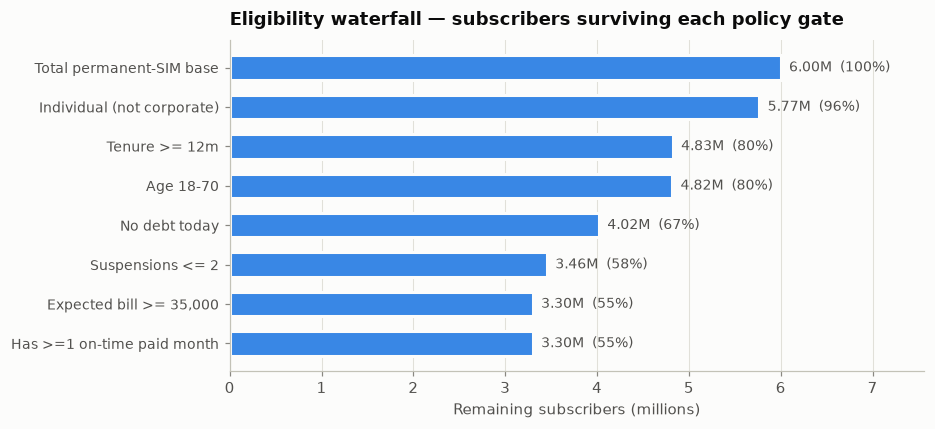

In [8]:
# ---- eligibility waterfall: ordered magnitude -> horizontal bars, one hue ramp
fig, ax = plt.subplots(figsize=(8.6, 4.0))
y = np.arange(len(WF))[::-1]
vals = WF["remaining_real"].to_numpy() / 1e6
ax.barh(y, vals, height=0.62, color=SEQ[3], edgecolor=C["surface"], linewidth=2)
for yi, v, p in zip(y, vals, WF["pct_of_base"]):
    ax.text(v + max(vals) * 0.015, yi, f"{v:,.2f}M  ({p:.0%})",
            va="center", ha="left", fontsize=9, color=C["ink2"])
ax.set_yticks(y); ax.set_yticklabels(WF["gate"], fontsize=9)
ax.set_xlim(0, max(vals) * 1.26)
style(ax, "Eligibility waterfall — subscribers surviving each policy gate",
      "Remaining subscribers (millions)", grid="x")
save(fig, "01_eligibility_waterfall.png"); plt.show()

### مقایسه با فیلتر ARPU — چرا معیار ریسک جامعه را بزرگ‌تر می‌کند

جدول زیر مستقیماً به نگرانی اصلی جواب می‌دهد: «فیلتر ARPU بالاتر از ۱۳۰ هزار، ۶ میلیون نفر
باقی می‌گذارد که کم است.» ببینیم دروازه‌های ریسک‌محور چه می‌کنند.

In [9]:
ARPU_MEAN = 130_000
scale = CONFIG["population_scale"]
comp = pd.DataFrame([
    dict(policy="(a) No filter",
         n=len(feat)),
    dict(policy=f"(b) ARPU filter only: bill >= {ARPU_MEAN:,}",
         n=int(feat["expected_bill"].ge(ARPU_MEAN).sum())),
    dict(policy="(c) Risk gates only (this notebook)",
         n=int(elig_mask.sum())),
    dict(policy="(d) Risk gates AND ARPU filter",
         n=int((elig_mask & feat["expected_bill"].ge(ARPU_MEAN).to_numpy()).sum())),
])
comp["subscribers_real"] = comp["n"] * scale
comp["share"] = comp["n"] / len(feat)
comp["mean_bill"] = [feat["expected_bill"].mean(),
                     feat.loc[feat["expected_bill"].ge(ARPU_MEAN), "expected_bill"].mean(),
                     elig["expected_bill"].mean(),
                     feat.loc[elig_mask & feat["expected_bill"].ge(ARPU_MEAN).to_numpy(), "expected_bill"].mean()]
comp.style.format({"n": "{:,.0f}", "subscribers_real": "{:,.0f}",
                   "share": "{:.1%}", "mean_bill": "{:,.0f}"})

,policy,n,subscribers_real,share,mean_bill
0,(a) No filter,"60,000","6,000,000",100.0%,"143,595"
1,"(b) ARPU filter only: bill >= 130,000","25,547","2,554,700",42.6%,"232,557"
2,(c) Risk gates only (this notebook),"33,006","3,300,600",55.0%,"150,039"
3,(d) Risk gates AND ARPU filter,"14,767","1,476,700",24.6%,"234,298"


## ۵. ساخت تارگت

$$y = 1 \iff \max_{j \in \text{outcome}} \text{DPD}_j \ge 60 \;\;\lor\;\; \#\{j : \text{DPD}_j > \text{grace}\} \ge 2$$

### دو نکتهٔ حرفه‌ای

**۱) ناحیهٔ نامشخص (indeterminate).** مشترکی که فقط یک ماه، فقط چند روز دیر پرداخت کرده، نه «خوب»
است نه «بد». در اسکورکارت‌های استاندارد این گروه از آموزش **حذف** می‌شود تا مرز بین دو کلاس تیز شود.
پرچم `EXCLUDE_INDETERMINATE` این امکان را می‌دهد؛ پیش‌فرض خاموش است تا اول اندازهٔ گروه را ببینید.

**۲) نرخ بد مطلوب.** اگر نرخ بد زیر ۳٪ درآمد، تارگت خیلی سخت‌گیر است و مدل داده کافی برای یادگیری
ندارد؛ اگر بالای ۲۵٪ شد، تارگت خیلی شل است و در عمل چیزی را تفکیک نمی‌کند. بازهٔ کاری خوب **۵–۱۵٪** است.
آستانه‌ها (`bad_dpd_threshold`, `bad_n_late_months`) را برای رسیدن به این بازه تنظیم کنید.

In [10]:
EXCLUDE_INDETERMINATE = False

def build_target(df, cfg):
    M, G = cfg["outcome_window_months"], cfg["grace_days"]
    O = df[[f"o_dtp_{j+1}" for j in range(M)]].to_numpy(float)
    max_dtp = O.max(1)
    n_late  = (O > G).sum(1)
    bad = ((max_dtp >= cfg["bad_dpd_threshold"]) | (n_late >= cfg["bad_n_late_months"])).astype(int)
    indet = ((bad == 0) & (n_late == 1)).astype(int)        # one mild slip: neither good nor bad
    out = df.copy()
    out["y"] = bad
    out["indeterminate"] = indet
    out["out_max_dpd"] = max_dtp
    out["out_n_late"]  = n_late
    return out

data = build_target(elig, CONFIG)
print(f"bad rate              : {data['y'].mean():.2%}")
print(f"indeterminate share   : {data['indeterminate'].mean():.2%}")
print(f"bads / goods          : {data['y'].sum():,} / {(1-data['y']).sum():,}")
print("\nbad rate by observation cohort (out-of-time drift check):")
print(data.groupby("obs_cohort")["y"].agg(["mean", "size"]).rename(
      columns={"mean": "bad_rate", "size": "n"}).to_string())

if EXCLUDE_INDETERMINATE:
    n0 = len(data); data = data.loc[data["indeterminate"].eq(0)].reset_index(drop=True)
    print(f"\nindeterminate excluded: {n0:,} -> {len(data):,}, bad rate now {data['y'].mean():.2%}")

bad rate              : 14.16%
indeterminate share   : 17.29%
bads / goods          : 4,675 / 28,331

bad rate by observation cohort (out-of-time drift check):
            bad_rate      n
obs_cohort                 
2025-03       0.1325  11469
2025-06       0.1332  11505
2025-09       0.1618  10032


## ۶. تحلیل اکتشافی، WOE و IV

**WOE (Weight of Evidence)** هر بازه از یک متغیر را به یک عدد تبدیل می‌کند:
$$\text{WOE}_b = \ln\frac{\text{سهم خوب‌ها در بازهٔ } b}{\text{سهم بد‌ها در بازهٔ } b}
\qquad(\text{بزرگ‌تر} = \text{کم‌ریسک‌تر})$$

**IV (Information Value)** قدرت کل متغیر است:
$$\text{IV} = \sum_b (\text{dist}^{good}_b - \text{dist}^{bad}_b)\cdot \text{WOE}_b$$

| IV | تفسیر |
|---|---|
| < ۰٫۰۲ | بی‌فایده — حذف |
| ۰٫۰۲ – ۰٫۱ | ضعیف ولی قابل استفاده |
| ۰٫۱ – ۰٫۳ | متوسط |
| ۰٫۳ – ۰٫۵ | قوی |
| **> ۰٫۵** | **مشکوک به نشت تارگت — بررسی کنید** |

> **توجه دربارهٔ دادهٔ مصنوعی:** در اجرای فعلی چند ویژگی IV بالای ۱ می‌گیرند. این **نشت نیست**،
> بلکه ساختگی بودن داده است: ویژگی‌ها و تارگت هر دو از یک متغیر پنهان $q$ تولید شده‌اند.
> روی دادهٔ واقعی انتظار داشته باشید IV قوی‌ترین ویژگی‌ها در بازهٔ **۰٫۲ تا ۰٫۵** بیفتد.
> اگر روی دادهٔ واقعی IV بالای ۰٫۸ دیدید، **واقعاً نشت است** و باید منبعش را پیدا کنید.

چرا WOE و نه خام: یکنواخت‌سازی روابط غیرخطی، مدیریت طبیعی مقادیر گمشده (خودشان یک بازه می‌شوند)،
مقاومت به مقادیر پرت، و اینکه ضرایب لجستیک مستقیماً به **جدول امتیاز قابل چاپ** تبدیل می‌شوند.

In [11]:
EPS = 0.5     # Laplace smoothing - keeps WOE finite in zero-bad bins

def fit_woe(x, y, n_bins=10, is_cat=False):
    s = pd.Series(x).reset_index(drop=True); y = np.asarray(y)
    if is_cat:
        key = s.astype("object").where(s.notna(), "__NA__").astype(str); edges = None
    else:
        xf = pd.to_numeric(s, errors="coerce")
        qs = np.linspace(0, 1, n_bins + 1)[1:-1]
        inner = np.unique(np.nanquantile(xf.dropna(), qs)) if xf.notna().any() else np.array([])
        edges = np.r_[-np.inf, inner, np.inf]
        key = pd.cut(xf, bins=edges).astype("object")
        key = key.where(xf.notna(), "__NA__").astype(str)
    tab = (pd.DataFrame({"k": key, "y": y}).groupby("k", observed=True)["y"]
           .agg(n="size", bad="sum").reset_index())
    tab["good"] = tab["n"] - tab["bad"]
    k = len(tab)
    tab["dist_bad"]  = (tab["bad"]  + EPS) / (tab["bad"].sum()  + EPS * k)
    tab["dist_good"] = (tab["good"] + EPS) / (tab["good"].sum() + EPS * k)
    tab["bad_rate"]  = tab["bad"] / tab["n"]
    tab["woe"]       = np.log(tab["dist_good"] / tab["dist_bad"])
    tab["iv_part"]   = (tab["dist_good"] - tab["dist_bad"]) * tab["woe"]
    return dict(table=tab, edges=edges, is_cat=is_cat, iv=float(tab["iv_part"].sum()),
                mapping=dict(zip(tab["k"], tab["woe"])))

def apply_woe(x, model):
    s = pd.Series(x).reset_index(drop=True)
    if model["is_cat"]:
        key = s.astype("object").where(s.notna(), "__NA__").astype(str)
    else:
        xf = pd.to_numeric(s, errors="coerce")
        key = pd.cut(xf, bins=model["edges"]).astype("object")
        key = key.where(xf.notna(), "__NA__").astype(str)
    return key.map(model["mapping"]).astype(float).fillna(0.0).to_numpy()

In [12]:
# ---------------- candidate feature list (protected + leakage excluded) -------
LEAK = (["y", "indeterminate", "out_max_dpd", "out_n_late", "subscriber_id", "obs_cohort",
         "is_individual", "goodpay_v1", "goodpay_v2"]
        + [f"o_dtp_{j+1}" for j in range(CONFIG["outcome_window_months"])]
        + [f"bill_m{j+1}" for j in range(CONFIG["obs_window_months"])]
        + [f"paid_m{j+1}" for j in range(CONFIG["obs_window_months"])]
        + [f"dtp_m{j+1}"  for j in range(CONFIG["obs_window_months"])])
# goodpay_v1/v2 are held out of the model but scored separately as benchmarks.

CAT_FEATURES = ["province"]
candidates = [c for c in data.columns
              if c not in LEAK + PROTECTED
              and (c in CAT_FEATURES or pd.api.types.is_numeric_dtype(data[c]))]
print(f"{len(candidates)} candidate features")

y_all = data["y"].to_numpy()
woe_models, iv_rows = {}, []
for c in candidates + ["goodpay_v1", "goodpay_v2"]:
    m = fit_woe(data[c], y_all, n_bins=10, is_cat=(c in CAT_FEATURES))
    woe_models[c] = m
    iv_rows.append(dict(feature=c, iv=m["iv"], n_bins=len(m["table"])))

IV = pd.DataFrame(iv_rows).sort_values("iv", ascending=False).reset_index(drop=True)
IV["strength"] = pd.cut(IV["iv"], [-1, .02, .1, .3, .5, 99],
                        labels=["useless", "weak", "medium", "strong", "SUSPECT"])
IV.head(25).style.format({"iv": "{:.4f}"})

58 candidate features


,feature,iv,n_bins,strength
0,dtp_mean,1.0778,10,SUSPECT
1,dtp_p75,1.0567,10,SUSPECT
2,pct_fast_pay,1.0450,6,SUSPECT
3,dtp_max,0.9663,10,SUSPECT
4,goodpay_v2,0.9324,8,SUSPECT
5,autopay_flag,0.8677,2,SUSPECT
6,dtp_std,0.7916,10,SUSPECT
7,n_late_months_10m,0.5335,3,SUSPECT
8,pct_late,0.5335,3,SUSPECT
9,n_suspensions_10m,0.5335,3,SUSPECT


### حکم دربارهٔ امتیاز خوش‌حسابی فعلی

دو ردیف `goodpay_v1` و `goodpay_v2` را در جدول بالا مقایسه کنید. سلول بعد اختلاف را
به‌صورت عددی و با **توزیع جامعه** نشان می‌دهد — یعنی همان «نقطهٔ کور» که گفتیم:
امتیاز فعلی روی اکثریتِ صفرقطعی تقریباً مسطح است.

In [13]:
cmp_rows = []
for name in ["goodpay_v1", "goodpay_v2"]:
    m = woe_models[name]
    s = data[name].to_numpy()
    cmp_rows.append(dict(score=name, iv=m["iv"],
                         gini=2 * roc_auc_score(y_all, -s) - 1,
                         n_distinct_bins=len(m["table"]),
                         pct_at_max=float((s >= 99.5).mean())))
CMP = pd.DataFrame(cmp_rows)
print(CMP.to_string(index=False))

zero_susp = data["n_suspensions_10m"].eq(0)
print(f"\nShare of the eligible base with ZERO suspensions: {zero_susp.mean():.1%}")
print("Inside that majority group, what still separates good from bad:")
print(data.loc[zero_susp].assign(
        fast=lambda d: pd.qcut(d['dtp_mean'], 4, labels=['Q1 fastest','Q2','Q3','Q4 slowest'])
      ).groupby('fast', observed=True)['y'].agg(bad_rate='mean', n='size').to_string())

     score     iv   gini  n_distinct_bins  pct_at_max
goodpay_v1 0.3923 0.3532                3      0.7357
goodpay_v2 0.9324 0.5121                8      0.2360

Share of the eligible base with ZERO suspensions: 73.6%
Inside that majority group, what still separates good from bad:
            bad_rate     n
fast                      
Q1 fastest    0.0318  6071
Q2            0.0390  6071
Q3            0.0593  6071
Q4 slowest    0.2112  6071


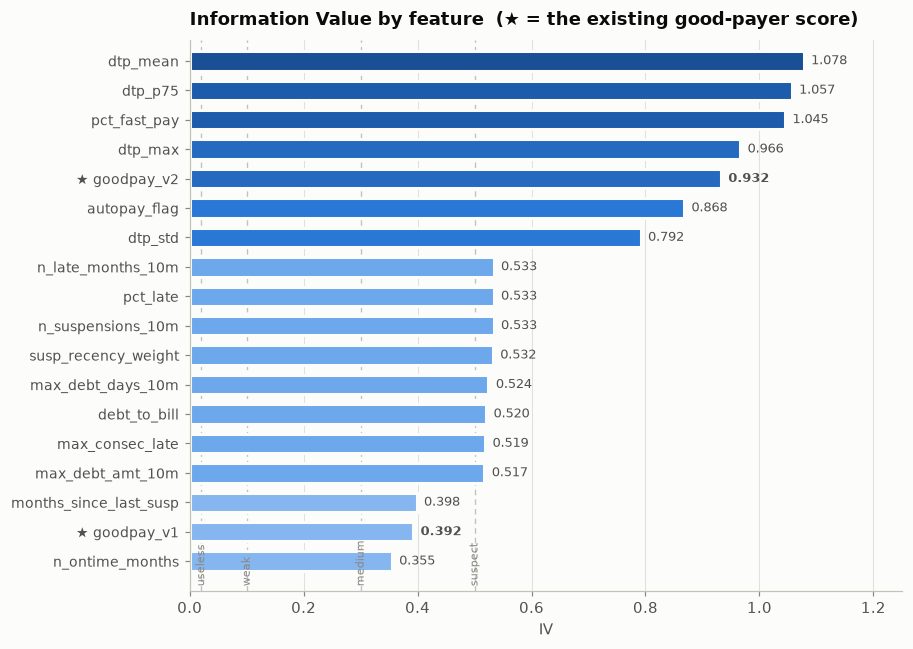

In [14]:
# ---- IV ranking: ordered magnitude -> horizontal bars, one sequential hue
top = IV.head(18).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.4, 6.0))
norm = (top["iv"] - top["iv"].min()) / max(top["iv"].max() - top["iv"].min(), 1e-9)
colors = [SEQ[min(int(v * (len(SEQ) - 1)), len(SEQ) - 1)] for v in norm]
bars = ax.barh(np.arange(len(top)), top["iv"], height=0.66,
               color=colors, edgecolor=C["surface"], linewidth=2)
for i, (v, f) in enumerate(zip(top["iv"], top["feature"])):
    ax.text(v + top["iv"].max() * 0.012, i, f"{v:.3f}", va="center",
            fontsize=8.5, color=C["ink2"],
            fontweight="bold" if f.startswith("goodpay") else "normal")
ax.set_yticks(np.arange(len(top)))
ax.set_yticklabels([f"★ {f}" if f.startswith("goodpay") else f for f in top["feature"]], fontsize=9)
for thr, lab in [(0.02, "useless"), (0.10, "weak"), (0.30, "medium"), (0.50, "suspect")]:
    if thr < top["iv"].max():
        ax.axvline(thr, color=C["axis"], lw=0.9, ls=(0, (4, 3)), zorder=0)
        ax.text(thr, -0.85, lab, fontsize=7.5, color=C["muted"],
                rotation=90, ha="center", va="bottom")
ax.set_ylim(-1.0, len(top) - 0.3)
style(ax, "Information Value by feature  (★ = the existing good-payer score)",
      "IV", grid="x")
ax.set_xlim(0, top["iv"].max() * 1.16)
save(fig, "02_information_value.png"); plt.show()

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


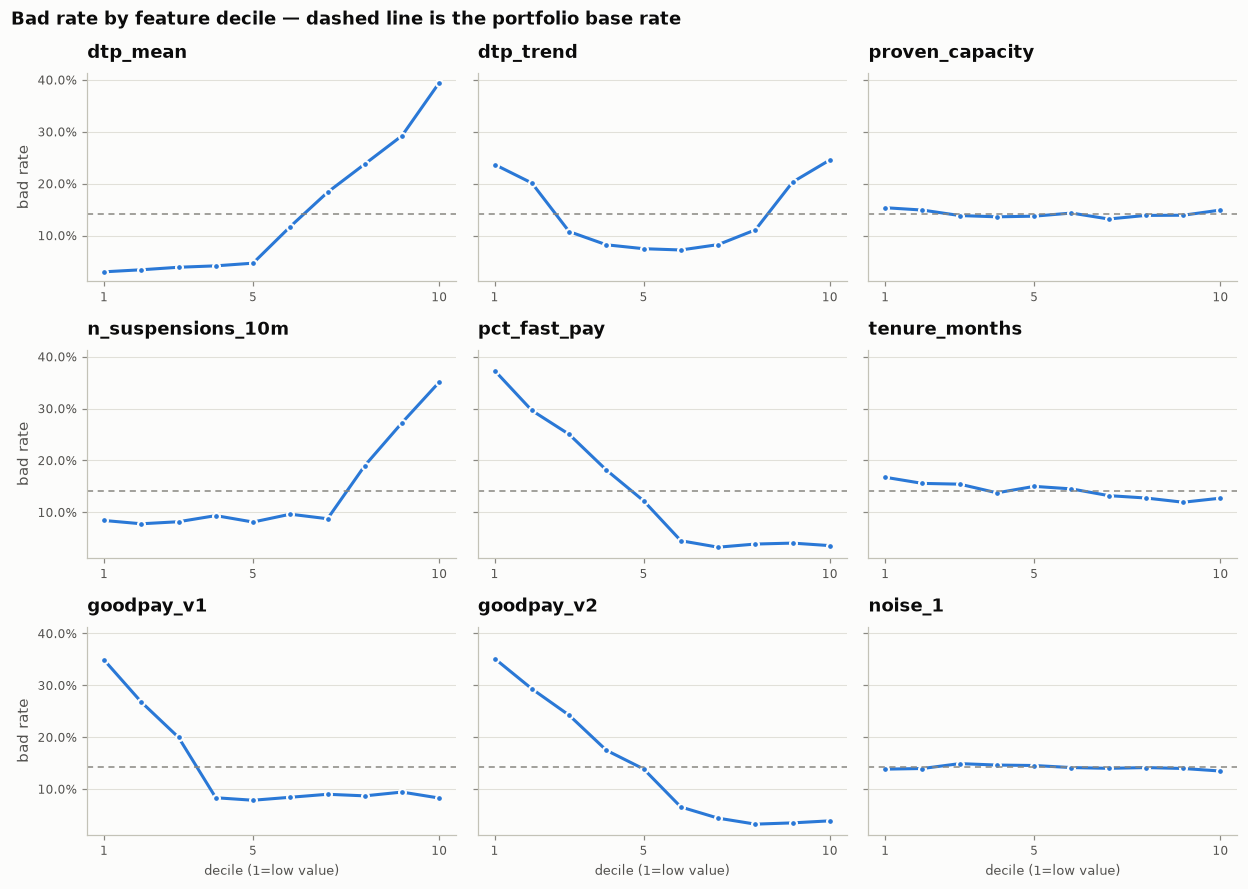

In [15]:
# ---- bad rate across deciles: small multiples, one hue (magnitude, not identity)
show = ["dtp_mean", "dtp_trend", "proven_capacity", "n_suspensions_10m",
        "pct_fast_pay", "tenure_months", "goodpay_v1", "goodpay_v2", "noise_1"]
fig, axes = plt.subplots(3, 3, figsize=(11.4, 8.2), sharey=True)
base_rate = y_all.mean()
for ax, c in zip(axes.ravel(), show):
    r = pd.Series(data[c]).rank(method="first")
    b = pd.qcut(r, 10, labels=False)
    g = pd.DataFrame({"b": b, "y": y_all}).groupby("b")["y"].agg(["mean", "size"])
    ax.plot(g.index + 1, g["mean"], color=C["s1"], marker="o", markersize=4.5,
            markeredgecolor=C["surface"], markeredgewidth=1.4)
    ax.axhline(base_rate, color=C["muted"], lw=1.0, ls=(0, (4, 3)))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xticks([1, 5, 10])
    style(ax, c, grid="y")
    ax.tick_params(labelsize=8); ax.title.set_fontsize(9.5)
axes[0, 0].set_ylabel("bad rate"); axes[1, 0].set_ylabel("bad rate"); axes[2, 0].set_ylabel("bad rate")
for ax in axes[2]: ax.set_xlabel("decile (1=low value)", fontsize=8.5)
fig.suptitle("Bad rate by feature decile — dashed line is the portfolio base rate",
             x=0.009, ha="left", fontsize=12, fontweight="600", color=C["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.965])
save(fig, "03_bad_rate_by_decile.png"); plt.show()

## ۷. تقسیم داده — تصادفی **و** خارج از زمان

در اعتبارسنجی، تست تصادفی به‌تنهایی بی‌معنی است. مدل باید روی **کوهورت زمانیِ بعدی** سنجیده شود،
چون در عمل مدلی که امروز می‌سازید را روی مشترکین ماه‌های آینده اجرا می‌کنید و توزیع جابه‌جا می‌شود
(تورم، تغییر تعرفه، فصل). افت Gini از تست به OOT، عدد واقعی‌ای است که باید گزارش کنید.

- **Train / Test:** کوهورت‌های ۲۰۲۵-۰۳ و ۲۰۲۵-۰۶، تقسیم ۷۰/۳۰ طبقه‌ای
- **OOT:** کوهورت ۲۰۲۵-۰۹ (آخرین) — **فقط یک بار** در پایان نگاه می‌شود

نکتهٔ مهم: WOE صرفاً روی **train** برازش می‌شود و بعد به test/OOT اعمال می‌شود. برازش WOE روی کل
داده، نشت است و Gini را به‌دروغ بالا می‌برد.

In [16]:
OOT_COHORT = "2025-09"
is_oot = data["obs_cohort"].eq(OOT_COHORT).to_numpy()
dev, oot = data.loc[~is_oot].reset_index(drop=True), data.loc[is_oot].reset_index(drop=True)
tr, te = train_test_split(dev, test_size=0.30, stratify=dev["y"],
                          random_state=CONFIG["seed"])
tr, te = tr.reset_index(drop=True), te.reset_index(drop=True)

for nm, d in [("train", tr), ("test", te), ("OOT", oot)]:
    print(f"{nm:<6} n={len(d):>7,}   bad rate={d['y'].mean():.2%}   "
          f"mean expected bill={d['expected_bill'].mean():>9,.0f}")

# Volumes are reported for the ENTIRE eligible base, while the policy is measured on
# the OOT cohort only. This factor reconciles the two - without it, "approved" and
# "eligible" would sit on different denominators.
ELIGIBLE_REAL = len(elig) * CONFIG["population_scale"]
POLICY_SCALE  = ELIGIBLE_REAL / len(oot)
print(f"\neligible base        : {ELIGIBLE_REAL:,} real subscribers")
print(f"scored on OOT        : {len(oot):,} rows")
print(f"POLICY_SCALE         : 1 scored row -> {POLICY_SCALE:,.1f} real subscribers")

train  n= 16,081   bad rate=13.28%   mean expected bill=  144,565
test   n=  6,893   bad rate=13.29%   mean expected bill=  145,021
OOT    n= 10,032   bad rate=16.18%   mean expected bill=  162,262

eligible base        : 3,300,600 real subscribers
scored on OOT        : 10,032 rows
POLICY_SCALE         : 1 scored row -> 329.0 real subscribers


## ۸. آموزش مدل‌ها و ارزیابی

### انتخاب ویژگی در سه مرحله
1. `IV >= 0.02` (چیزی برای گفتن داشته باشد) و `IV <= 0.8` (مشکوک به نشت نباشد)
2. حذف هم‌خطی: از هر جفت با `|r| > 0.80`، آن که IV کمتری دارد حذف می‌شود
3. حذف ضرایب با علامت غیرمنتظره (در WOE، ضریب باید منفی باشد: WOE بالاتر = کم‌ریسک‌تر)

### دو مدل
- **champion — لجستیک روی WOE:** چیزی که در عمل اجرا می‌کنید. خروجی‌اش جدول امتیاز است.
- **challenger — Gradient Boosting روی ویژگی خام:** سقف قدرت تفکیک. اگر فاصلهٔ Gini بیش از
  حدود ۰٫۰۴ شد، مشکل در binning یا ویژگی‌های گمشده است نه در لجستیک بودن مدل.

### معیارها
$\text{Gini} = 2\text{AUC}-1$ (قدرت تفکیک) · $\text{KS} = \max(TPR-FPR)$ (بهترین جداسازی) ·
**Brier** (دقت کالیبراسیون) · یکنواختی نرخ بد در دهک‌ها (قابل اتکا بودن رتبه‌بندی)

In [17]:
def select_features(train_df, iv_tbl, cands, min_iv=0.02, max_iv=0.80, max_corr=0.80):
    keep = [f for f in cands if min_iv <= float(iv_tbl.loc[iv_tbl.feature == f, "iv"].iloc[0]) <= max_iv]
    order = iv_tbl.set_index("feature").loc[keep, "iv"].sort_values(ascending=False).index.tolist()
    num = [f for f in order if f not in CAT_FEATURES]
    corr = train_df[num].corr().abs()
    dropped, final = [], []
    for f in order:
        if f in CAT_FEATURES: final.append(f); continue
        if any(corr.loc[f, g] > max_corr for g in final if g in num):
            dropped.append(f); continue
        final.append(f)
    return final, dropped

FEATURES, DROPPED_CORR = select_features(tr, IV, candidates)
print(f"selected {len(FEATURES)} features; dropped {len(DROPPED_CORR)} for collinearity")
print("dropped:", DROPPED_CORR)

# ---- WOE fitted on TRAIN ONLY, then applied everywhere -----------------
woe_tr = {f: fit_woe(tr[f], tr["y"].to_numpy(), n_bins=10, is_cat=(f in CAT_FEATURES))
          for f in FEATURES}

def woe_matrix(df, models, feats):
    return pd.DataFrame({f"woe_{f}": apply_woe(df[f], models[f]) for f in feats})

Xtr, Xte, Xoot = (woe_matrix(d, woe_tr, FEATURES) for d in (tr, te, oot))
ytr, yte, yoot = tr["y"].to_numpy(), te["y"].to_numpy(), oot["y"].to_numpy()

# ---- drop wrong-signed coefficients (expected sign on WOE is negative) --
for _ in range(6):
    lr = LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs").fit(Xtr, ytr)
    bad_sign = [c for c, b in zip(Xtr.columns, lr.coef_[0]) if b > 0]
    if not bad_sign: break
    print("dropping wrong-signed:", bad_sign)
    Xtr, Xte, Xoot = (X.drop(columns=bad_sign) for X in (Xtr, Xte, Xoot))
FEATURES = [c[4:] for c in Xtr.columns]
print(f"\nfinal scorecard features ({len(FEATURES)}): {FEATURES}")

selected 12 features; dropped 9 for collinearity
dropped: ['n_late_months_10m', 'n_suspensions_10m', 'susp_recency_weight', 'debt_to_bill', 'max_consec_late', 'months_since_last_susp', 'dtp_shift_3m', 'n_partial_payments', 'pay_ratio_mean']


dropping wrong-signed: ['woe_max_debt_amt_10m']
dropping wrong-signed: ['woe_max_debt_days_10m']

final scorecard features (10): ['dtp_std', 'pct_late', 'n_ontime_months', 'dtp_trend', 'bureau_score', 'pay_ratio_min', 'home_cell_stability', 'active_days_ratio', 'n_services', 'distinct_contacts']


In [18]:
def metrics(y, p):
    auc = roc_auc_score(y, p)
    fpr, tpr, _ = roc_curve(y, p)
    return dict(n=len(y), bad_rate=float(np.mean(y)), auc=auc, gini=2 * auc - 1,
                ks=float(np.max(tpr - fpr)), brier=brier_score_loss(y, np.clip(p, 1e-6, 1 - 1e-6)))

# champion
champ = LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs").fit(Xtr, ytr)
p_tr, p_te, p_oot = (champ.predict_proba(X)[:, 1] for X in (Xtr, Xte, Xoot))

# challenger on RAW features (gets the categorical as ordinal codes)
def raw_matrix(df, feats):
    R = df[feats].copy()
    for c in feats:
        if c in CAT_FEATURES: R[c] = R[c].astype("category").cat.codes
    return R.astype(float)

RAW_F = [f for f in candidates if f in FEATURES or f in DROPPED_CORR]
gbm = HistGradientBoostingClassifier(
        max_depth=4, max_iter=350, learning_rate=0.06, l2_regularization=1.0,
        min_samples_leaf=120, early_stopping=True, validation_fraction=0.15,
        random_state=CONFIG["seed"]).fit(raw_matrix(tr, RAW_F), ytr)
g_tr, g_te, g_oot = (gbm.predict_proba(raw_matrix(d, RAW_F))[:, 1] for d in (tr, te, oot))

REPORT = pd.DataFrame([
    dict(model="Logistic/WOE (champion)", split="train", **metrics(ytr, p_tr)),
    dict(model="Logistic/WOE (champion)", split="test",  **metrics(yte, p_te)),
    dict(model="Logistic/WOE (champion)", split="OOT",   **metrics(yoot, p_oot)),
    dict(model="GBM (challenger)",        split="train", **metrics(ytr, g_tr)),
    dict(model="GBM (challenger)",        split="test",  **metrics(yte, g_te)),
    dict(model="GBM (challenger)",        split="OOT",   **metrics(yoot, g_oot)),
    dict(model="goodpay_v1 (current)",    split="OOT",   **metrics(yoot, -oot["goodpay_v1"].to_numpy())),
    dict(model="goodpay_v2 (enhanced)",   split="OOT",   **metrics(yoot, -oot["goodpay_v2"].to_numpy())),
])
REPORT.style.format({"bad_rate": "{:.2%}", "auc": "{:.4f}", "gini": "{:.4f}",
                     "ks": "{:.4f}", "brier": "{:.5f}", "n": "{:,.0f}"})

,model,split,n,bad_rate,auc,gini,ks,brier
0,Logistic/WOE (champion),train,"16,081",13.28%,0.7547,0.5093,0.4117,0.10347
1,Logistic/WOE (champion),test,"6,893",13.29%,0.7575,0.5150,0.4178,0.10336
2,Logistic/WOE (champion),OOT,"10,032",16.18%,0.7787,0.5575,0.4534,0.11846
3,GBM (challenger),train,"16,081",13.28%,0.7877,0.5754,0.4441,0.10009
4,GBM (challenger),test,"6,893",13.29%,0.7604,0.5207,0.4304,0.10289
5,GBM (challenger),OOT,"10,032",16.18%,0.7858,0.5715,0.4666,0.11742
6,goodpay_v1 (current),OOT,"10,032",16.18%,0.6894,0.3788,0.3695,0.16178
7,goodpay_v2 (enhanced),OOT,"10,032",16.18%,0.7762,0.5523,0.4537,0.16178


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


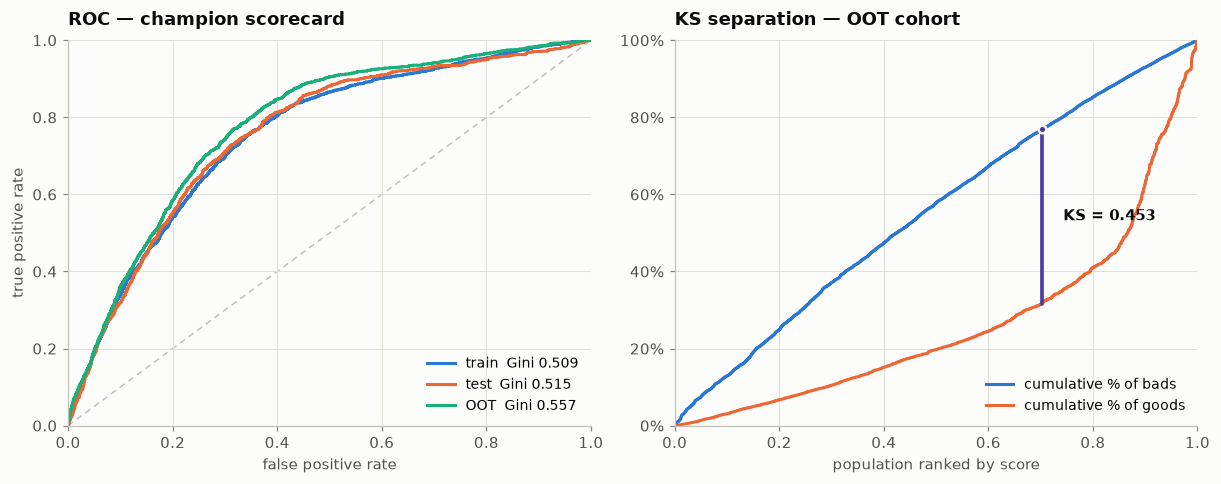

In [19]:
# ---- ROC and KS. Three splits = identity -> fixed categorical slots + legend
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))
ax = axes[0]
for (nm, y_, p_), col in zip([("train", ytr, p_tr), ("test", yte, p_te), ("OOT", yoot, p_oot)],
                             [C["s1"], C["s2"], C["s3"]]):
    fpr, tpr, _ = roc_curve(y_, p_)
    ax.plot(fpr, tpr, color=col, label=f"{nm}  Gini {2*roc_auc_score(y_, p_)-1:.3f}")
ax.plot([0, 1], [0, 1], color=C["axis"], lw=1.0, ls=(0, (4, 3)), zorder=0)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
style(ax, "ROC — champion scorecard", "false positive rate", "true positive rate", grid="both")
ax.legend(loc="lower right")

ax = axes[1]
fpr, tpr, thr = roc_curve(yoot, p_oot)
pct = np.linspace(0, 1, len(tpr))
ax.plot(pct, tpr, color=C["s1"], label="cumulative % of bads")
ax.plot(pct, fpr, color=C["s2"], label="cumulative % of goods")
i = int(np.argmax(tpr - fpr))
ax.plot([pct[i], pct[i]], [fpr[i], tpr[i]], color=C["s7"], lw=2.4, solid_capstyle="round")
ax.plot([pct[i]], [tpr[i]], "o", color=C["s7"], markeredgecolor=C["surface"], markeredgewidth=1.6)
ax.annotate(f"KS = {tpr[i]-fpr[i]:.3f}", (pct[i], (tpr[i] + fpr[i]) / 2),
            xytext=(14, 0), textcoords="offset points", fontsize=9.5,
            color=C["ink"], fontweight="600", va="center")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
style(ax, "KS separation — OOT cohort", "population ranked by score", grid="both")
ax.legend(loc="lower right")
save(fig, "04_roc_ks.png"); plt.show()

## ۹. جدول امتیاز، کالیبراسیون و PD

### الف) جدول امتیاز قابل چاپ
ضرایب لجستیک با مقیاس‌گذاری استاندارد به امتیاز تبدیل می‌شوند:
$$\text{factor} = \frac{\text{PDO}}{\ln 2},\qquad
\text{offset} = \text{base} - \text{factor}\cdot\ln(\text{base odds})$$
$$\text{Score} = \text{offset} - \text{factor}\Big(\beta_0 + \sum_i \beta_i\,\text{WOE}_i\Big)$$
با تنظیمات فعلی: امتیاز ۶۰۰ یعنی شانس ۲۰ به ۱ خوب به بد، و هر **۴۰ امتیاز** این شانس را **دو برابر** می‌کند.
این جدول چیزی است که به تیم عملیات و ریسک تحویل می‌دهید — بدون نیاز به اجرای پایتون.

### ب) کالیبراسیون
Gini می‌گوید رتبه‌بندی درست است؛ **کالیبراسیون** می‌گوید عددِ PD درست است. برای قیمت‌گذاری و
محاسبهٔ زیان، به عدد نیاز دارید نه رتبه. بازکالیبراسیون Platt روی **test** برازش و روی **OOT** سنجیده می‌شود.

### ج) ضریب افزایندهٔ شوک پرداخت — جبران سوگیری تارگت جانشین
تارگت proxy فقط توان پرداخت صورتحساب **معمولی** را سنجیده. وقتی قسط اضافه می‌شود، جریان خروجی
بزرگ‌تر از چیزی است که اثبات شده. پس PD را به‌اندازهٔ شدت این شوک بالا می‌بریم:

$$\text{shock} = \frac{\text{قسط} + \mathbb{E}[\text{bill}]}{P},\qquad
\text{logit}(PD^{adj}) = \text{logit}(PD) + \kappa\cdot\max(0,\ \text{shock}-1)$$

$\kappa = 0.55$ یک فرض محافظه‌کارانه است؛ **بعد از ۶ ماه دادهٔ واقعی آن را از نو برازش کنید.**
چون سقف به PD وابسته است و PD به سقف، یک **تکرار نقطهٔ ثابت** می‌زنیم.

In [20]:
factor = CONFIG["score_pdo"] / np.log(2)
offset = CONFIG["score_base"] - factor * np.log(CONFIG["score_base_odds"])
b0, betas = float(champ.intercept_[0]), dict(zip(FEATURES, champ.coef_[0]))
k_f = len(FEATURES)

rows = []
for f in FEATURES:
    t = woe_tr[f]["table"].copy()
    t["feature"] = f
    t["points"] = (-(betas[f] * t["woe"] + b0 / k_f) * factor + offset / k_f).round(1)
    rows.append(t[["feature", "k", "n", "bad_rate", "woe", "points"]]
                .rename(columns={"k": "bin", "n": "count"}))
POINTS = pd.concat(rows, ignore_index=True)

def score_of(X_woe):
    lin = b0 + sum(betas[f] * X_woe[f"woe_{f}"] for f in FEATURES)
    return offset - factor * lin

score_oot = score_of(Xoot).to_numpy()
print(f"factor={factor:.2f}  offset={offset:.1f}")
print(f"OOT score: min={score_oot.min():.0f}  p5={np.percentile(score_oot,5):.0f}  "
      f"median={np.median(score_oot):.0f}  p95={np.percentile(score_oot,95):.0f}  max={score_oot.max():.0f}")
POINTS.to_csv(f"{OUT_DIR}/scorecard_points.csv", index=False)
POINTS.head(22).style.format({"bad_rate": "{:.2%}", "woe": "{:+.3f}",
                              "points": "{:.1f}", "count": "{:,.0f}"})

factor=57.71  offset=427.1
OOT score: min=433  p5=467  median=557  p95=651  max=707


,feature,bin,count,bad_rate,woe,points
0,dtp_std,"(-inf, 1.212]","1,609",4.79%,+1.110,103.6
1,dtp_std,"(1.212, 1.372]","1,608",3.42%,+1.458,119.3
2,dtp_std,"(1.372, 1.497]","1,608",3.11%,+1.555,123.7
3,dtp_std,"(1.497, 1.654]","1,608",3.54%,+1.421,117.6
4,dtp_std,"(1.654, 3.968]","1,608",9.27%,+0.404,71.8
5,dtp_std,"(3.968, 5.098]","1,608",22.20%,-0.621,25.5
6,dtp_std,"(5.098, 5.813]","1,608",20.21%,-0.502,30.9
7,dtp_std,"(5.813, 6.479]","1,608",22.95%,-0.664,23.6
8,dtp_std,"(6.479, 7.305]","1,608",20.27%,-0.506,30.7
9,dtp_std,"(7.305, inf]","1,608",23.07%,-0.671,23.3


observed bad rate (OOT) : 16.178%
mean PD uncalibrated    : 13.174%   Brier 0.11846
mean PD calibrated      : 13.364%   Brier 0.11819


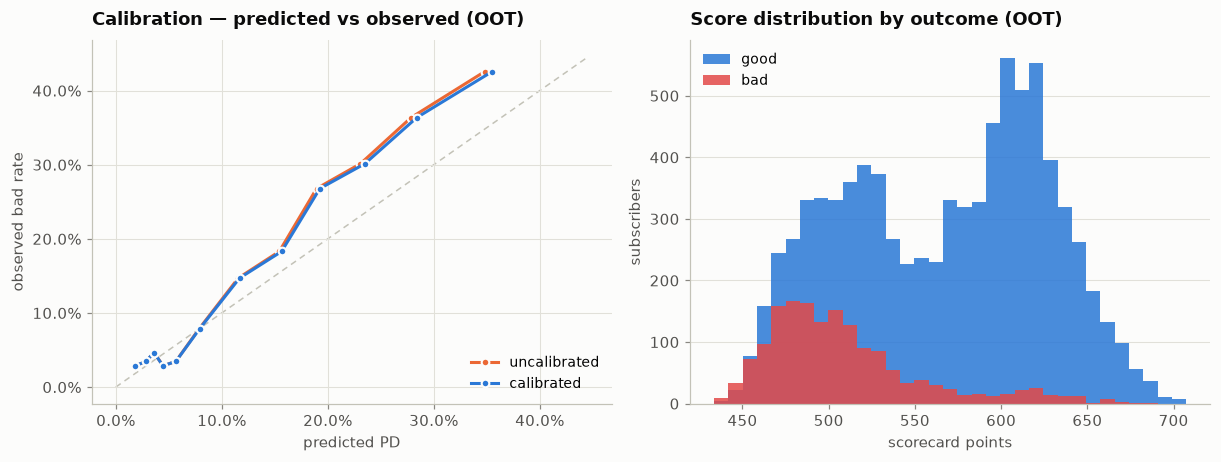

In [21]:
def logit(p): return np.log(np.clip(p, 1e-9, 1 - 1e-9) / (1 - np.clip(p, 1e-9, 1 - 1e-9)))
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

# ---- Platt recalibration: fitted on TEST, judged on OOT ----------------
cal = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_te).reshape(-1, 1), yte)
def calibrate(p): return cal.predict_proba(logit(p).reshape(-1, 1))[:, 1]
pd_oot_raw, pd_oot = p_oot, calibrate(p_oot)

def anchor(p, target):
    if target is None: return p
    s = brentq(lambda d: sigmoid(logit(p) + d).mean() - target, -8, 8)
    print(f"anchored mean PD {p.mean():.3%} -> {target:.3%} (logit shift {s:+.3f})")
    return sigmoid(logit(p) + s)
pd_oot = anchor(pd_oot, CONFIG["anchor_central_pd"])

print(f"observed bad rate (OOT) : {yoot.mean():.3%}")
print(f"mean PD uncalibrated    : {pd_oot_raw.mean():.3%}   Brier {brier_score_loss(yoot, pd_oot_raw):.5f}")
print(f"mean PD calibrated      : {pd_oot.mean():.3%}   Brier {brier_score_loss(yoot, pd_oot):.5f}")

# ---- reliability curve
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.3))
ax = axes[0]
for (nm, p_), col in zip([("uncalibrated", pd_oot_raw), ("calibrated", pd_oot)], [C["s2"], C["s1"]]):
    b = pd.qcut(pd.Series(p_).rank(method="first"), 12, labels=False)
    g = pd.DataFrame({"b": b, "p": p_, "y": yoot}).groupby("b").agg(pred=("p", "mean"), obs=("y", "mean"))
    ax.plot(g["pred"], g["obs"], marker="o", color=col, label=nm,
            markeredgecolor=C["surface"], markeredgewidth=1.4)
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], color=C["axis"], lw=1.0, ls=(0, (4, 3)), zorder=0)
ax.xaxis.set_major_formatter(PercentFormatter(1.0)); ax.yaxis.set_major_formatter(PercentFormatter(1.0))
style(ax, "Calibration — predicted vs observed (OOT)", "predicted PD", "observed bad rate", grid="both")
ax.legend(loc="lower right")

ax = axes[1]
bins = np.linspace(score_oot.min(), score_oot.max(), 34)
ax.hist(score_oot[yoot == 0], bins=bins, color=C["s1"], alpha=0.85, label="good", lw=0)
ax.hist(score_oot[yoot == 1], bins=bins, color=C["s8"], alpha=0.85, label="bad", lw=0)
style(ax, "Score distribution by outcome (OOT)", "scorecard points", "subscribers", grid="y")
ax.yaxis.set_major_formatter(TOMAN_FMT); ax.legend(loc="upper left")
save(fig, "05_calibration_scores.png"); plt.show()

## ۱۰–۱۱. رتبه‌بندی ریسک و موتور سقف اعتبار

رتبه از PD می‌آید، و سقف از **کمینهٔ چهار قید**:

| قید | فرمول | چه چیزی را محدود می‌کند |
|---|---|---|
| توان پرداخت | $\frac{n(\alpha_g P - \mathbb{E}[bill])}{1+f}$ | شوک صورتحساب |
| نسبت به مصرف | $m_g \cdot \mathbb{E}[bill]$ | تناسب با اندازهٔ مشتری |
| وثیقه | $h\cdot V_{sim}$ | زیان در بدترین حالت |
| سقف رتبه | $C_g$ | ریسک مدل و تمرکز |

**تحلیل قید فعال (binding constraint) حتماً نگاه شود:** اگر برای ۸۰٪ جامعه قید «سقف مطلق رتبه»
فعال باشد، یعنی پارامتر $C_g$ دارد سیاست را تعیین می‌کند نه مدل — و با تورم باید بازنگری شود.

In [22]:
def assign_grade(pdv, policy=GRADE_POLICY):
    e = policy["pd_upper"].to_numpy()
    return policy["grade"].to_numpy()[np.clip(np.searchsorted(e, pdv, side="left"), 0, len(e) - 1)]

def limit_engine(df, pdv, cfg, alpha_scale=1.0):
    pol = GRADE_POLICY.set_index("grade")
    g      = assign_grade(pdv)
    alpha  = pol.loc[g, "alpha"].to_numpy() * alpha_scale
    mult   = pol.loc[g, "arpu_mult"].to_numpy()
    cap_ab = pol.loc[g, "abs_cap"].to_numpy().astype(float)
    P = df["proven_capacity"].to_numpy(float)
    E = df["expected_bill"].to_numpy(float)
    n, f = cfg["n_installments"], cfg["fee_rate_total"]

    cap_aff  = np.maximum(alpha * P - E, 0.0) * n / (1 + f)       # affordability
    cap_arpu = mult * E                                           # size proportionality
    cap_coll = np.full_like(cap_aff, cfg["sim_haircut"] * cfg["sim_value_toman"])
    caps = np.vstack([cap_aff, cap_arpu, cap_coll, cap_ab])
    L = caps.min(0)
    L = np.where(alpha <= 0, 0.0, np.floor(L / 10_000) * 10_000)   # round down to 10k
    binding = np.array(["affordability", "size_vs_bill", "sim_collateral", "grade_cap"])[caps.argmin(0)]
    return L, L * (1 + f) / n, g, binding

def shock_adjust(pd_base, inst, E, P, k):
    shock = (inst + E) / np.maximum(P, 1.0)
    return sigmoid(logit(pd_base) + k * np.maximum(0.0, shock - 1.0)), shock

def run_policy(df, pd_base, cfg, pd_cutoff, alpha_scale=1.0, n_iter=3):
    E, P = df["expected_bill"].to_numpy(float), df["proven_capacity"].to_numpy(float)
    pdv = pd_base.copy()
    for _ in range(n_iter):                       # fixed point: limit <-> PD
        L, inst, g, binding = limit_engine(df, pdv, cfg, alpha_scale)
        pdv, shock = shock_adjust(pd_base, inst, E, P, cfg["shock_uplift_k"])
    approve = (L > 0) & (pd_base <= pd_cutoff)

    ead = L * cfg["ead_factor"]
    el  = pdv * cfg["lgd"] * ead
    fee = L * cfg["fee_rate_total"]
    tel = L * cfg["incremental_rev_share"] * cfg["telco_gross_margin"]
    avg_life_y = 0.625 * cfg["n_installments"] / 12.0
    fnd = L * cfg["cost_of_funds_annual"] * avg_life_y
    net = fee + tel - el - fnd - cfg["opex_per_loan"]

    res = pd.DataFrame(dict(grade=g, pd_base=pd_base, pd_adj=pdv, shock=shock,
                            limit=L, installment=inst, binding=binding, approve=approve,
                            ead=ead, el=el, fee=fee, telco=tel, funding=fnd, net=net,
                            expected_bill=E, proven_capacity=P, y=df["y"].to_numpy()))
    return res

def summarise(res, cfg, label="", scale=None):
    # `scale` converts one scored row into real subscribers. The model is scored on
    # the OOT cohort only, but the committee needs the numbers for the WHOLE eligible
    # base, so volumes are extrapolated by POLICY_SCALE (set just after the split).
    a = res.loc[res["approve"]]
    s_ = scale if scale is not None else POLICY_SCALE
    if len(a) == 0:
        return dict(scenario=label, n_approved=0, approval_rate=0.0)
    return dict(
        scenario=label,
        n_approved=int(len(a)), approval_rate=len(a) / len(res),
        n_approved_real=int(len(a) * s_),
        avg_limit=a["limit"].mean(), median_limit=a["limit"].median(),
        avg_installment=a["installment"].mean(),
        disbursement_real=a["limit"].sum() * s_,
        wavg_pd=float(np.average(a["pd_adj"], weights=a["limit"])),
        realised_bad_rate=float(a["y"].mean()),
        el_real=a["el"].sum() * s_, el_ratio=a["el"].sum() / a["limit"].sum(),
        net_real=a["net"].sum() * s_, net_per_loan=a["net"].mean(),
        return_on_disbursement=a["net"].sum() / a["limit"].sum(),
        concentration_DE=a.loc[a["grade"].isin(["D", "E"]), "limit"].sum() / a["limit"].sum(),
    )

BASE_CUTOFF = 0.10
res_base = run_policy(oot, pd_oot, CONFIG, pd_cutoff=BASE_CUTOFF, alpha_scale=1.0)
print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v)
                  for k, v in summarise(res_base, CONFIG, "base").items()}, indent=2))

{
  "scenario": "base",
  "n_approved": 5105,
  "approval_rate": 0.5089,
  "n_approved_real": 1679581,
  "avg_limit": 309723.8002,
  "median_limit": 280000.0,
  "avg_installment": 80528.1881,
  "disbursement_real": 520206407894.7369,
  "wavg_pd": 0.0438,
  "realised_bad_rate": 0.0437,
  "el_real": 8780759123.8113,
  "el_ratio": 0.0169,
  "net_real": 62046949085.4192,
  "net_per_loan": 36941.9072,
  "return_on_disbursement": 0.1193,
  "concentration_DE": 0.1072
}


In [23]:
# ---- grade table: PD band, population, observed bad rate, limits, loss
GT = (res_base.groupby("grade")
      .agg(n=("grade", "size"), mean_pd=("pd_adj", "mean"), observed_bad=("y", "mean"),
           mean_limit=("limit", "mean"), mean_installment=("installment", "mean"),
           approved=("approve", "sum"))
      .reindex(GRADE_POLICY["grade"]).fillna(0))
GT["share"] = GT["n"] / GT["n"].sum()
GT["share_real"] = (GT["n"] * CONFIG["population_scale"]).astype(np.int64)
GT = GT.join(GRADE_POLICY.set_index("grade")[["pd_upper", "alpha", "arpu_mult", "abs_cap"]])
GT["monotonic_ok"] = GT["observed_bad"].diff().fillna(0) >= -1e-9
GT.to_csv(f"{OUT_DIR}/grade_table.csv")
GT[["n", "share", "share_real", "pd_upper", "mean_pd", "observed_bad",
    "mean_limit", "mean_installment", "approved", "monotonic_ok"]].style.format(
    {"n": "{:,.0f}", "share": "{:.1%}", "share_real": "{:,.0f}", "pd_upper": "{:.3f}",
     "mean_pd": "{:.2%}", "observed_bad": "{:.2%}", "mean_limit": "{:,.0f}",
     "mean_installment": "{:,.0f}", "approved": "{:,.0f}"})

,n,share,share_real,pd_upper,mean_pd,observed_bad,mean_limit,mean_installment,approved,monotonic_ok
grade,,,,,,,,,,
A,333,3.3%,"33,300",0.020,1.66%,2.10%,"423,213","110,035",333,True
B,"1,896",18.9%,"189,600",0.040,3.23%,3.90%,"379,684","98,718","1,896",True
C,"1,977",19.7%,"197,700",0.070,5.33%,3.44%,"278,584","72,432","1,977",False
D,"1,262",12.6%,"126,200",0.120,9.28%,9.90%,"190,357","49,493",899,True
E,"1,799",17.9%,"179,900",0.200,16.24%,20.07%,"111,984","29,116",0,True
F,"2,365",23.6%,"236,500",0.350,26.66%,34.00%,0,0,0,True
G,400,4.0%,"40,000",1.001,38.41%,46.00%,0,0,0,True


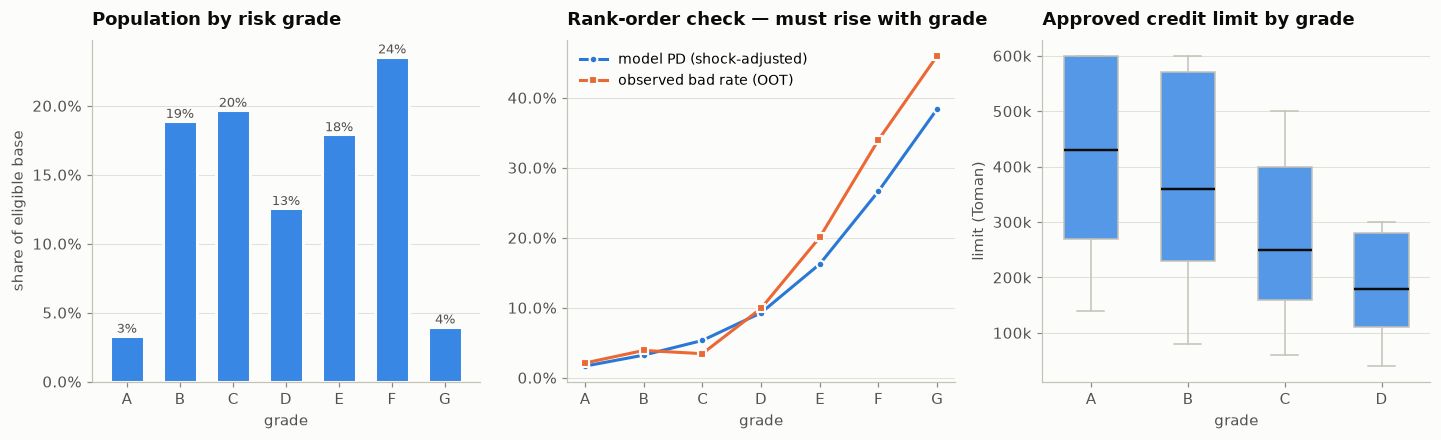

In [24]:
# ---- grade panel. Two measures of different scale -> two axes, never dual-y
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1))
gl = GT.index.tolist(); xs = np.arange(len(gl))

ax = axes[0]
ax.bar(xs, GT["share"], width=0.64, color=SEQ[3], edgecolor=C["surface"], linewidth=2)
for x, v in zip(xs, GT["share"]):
    if v > 0.004: ax.text(x, v, f"{v:.0%}", ha="center", va="bottom", fontsize=8.5, color=C["ink2"])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
style(ax, "Population by risk grade", "grade", "share of eligible base")
ax.set_xticks(xs); ax.set_xticklabels(gl)

ax = axes[1]
ax.plot(xs, GT["mean_pd"], marker="o", color=C["s1"], label="model PD (shock-adjusted)",
        markeredgecolor=C["surface"], markeredgewidth=1.4)
ax.plot(xs, GT["observed_bad"], marker="s", color=C["s2"], label="observed bad rate (OOT)",
        markeredgecolor=C["surface"], markeredgewidth=1.4)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
style(ax, "Rank-order check — must rise with grade", "grade")
ax.set_xticks(xs); ax.set_xticklabels(gl); ax.legend(loc="upper left")

ax = axes[2]
ap = res_base.loc[res_base["approve"]]
gl2 = [g for g in gl if (ap["grade"] == g).any()]
bp = ax.boxplot([ap.loc[ap["grade"] == g, "limit"] for g in gl2], positions=np.arange(len(gl2)),
                widths=0.56, patch_artist=True, showfliers=False, medianprops=dict(color=C["ink"], lw=1.6))
for p in bp["boxes"]: p.set_facecolor(SEQ[2]); p.set_edgecolor(C["axis"]); p.set_linewidth(1.0)
for w in bp["whiskers"] + bp["caps"]: w.set_color(C["axis"])
ax.yaxis.set_major_formatter(TOMAN_FMT)
style(ax, "Approved credit limit by grade", "grade", "limit (Toman)")
ax.set_xticks(np.arange(len(gl2))); ax.set_xticklabels(gl2)
save(fig, "06_grades.png"); plt.show()

In [25]:
# ---- which constraint actually sets the limit?
ap = res_base.loc[res_base["approve"]].copy()
BIND = (ap
        .groupby("binding")
        .agg(n=("binding", "size"), avg_limit=("limit", "mean"), share_of_disb=("limit", "sum")))
BIND["share_of_subs"] = BIND["n"] / BIND["n"].sum()
BIND["share_of_disb"] = BIND["share_of_disb"] / BIND["share_of_disb"].sum()
print("Binding constraint on the approved book\n")
print(BIND[["n", "share_of_subs", "avg_limit", "share_of_disb"]]
      .sort_values("n", ascending=False).to_string(
          formatters={"n": "{:,.0f}".format, "share_of_subs": "{:.1%}".format,
                      "avg_limit": "{:,.0f}".format, "share_of_disb": "{:.1%}".format}))

print(f"\nPayment-shock ratio on approved loans (installment + bill) / proven capacity:")
print(ap["shock"].describe(percentiles=[.5, .9, .99]).to_string())
print(f"\nPD uplift from the shock adjustment: "
      f"{ap['pd_base'].mean():.3%} -> {ap['pd_adj'].mean():.3%} "
      f"({ap['pd_adj'].mean()/ap['pd_base'].mean()-1:+.1%})")

Binding constraint on the approved book

                   n share_of_subs avg_limit share_of_disb
binding                                                   
size_vs_bill   3,375         66.1%   254,637         54.4%
affordability    665         13.0%   264,872         11.1%
sim_collateral   549         10.8%   600,000         20.8%
grade_cap        516         10.1%   418,992         13.7%

Payment-shock ratio on approved loans (installment + bill) / proven capacity:
count   5,105.0000
mean        1.1192
std         0.2683
min         0.1180
50%         1.1465
90%         1.4432
99%         1.6192
max         1.6982

PD uplift from the shock adjustment: 4.485% -> 4.868% (+8.5%)


## ۱۲. زیان مورد انتظار و اقتصاد واحد

$$EL = PD^{adj} \times LGD \times EAD,\qquad EAD = L \times 0.70$$

**EAD = 0.70L** چون نکول معمولاً بعد از پرداخت یک یا دو قسط رخ می‌دهد، نه در روز صفر.
**LGD = 0.55** یعنی ۴۵٪ وصول نهایی — در تلکو این عدد از وام نقدی بانکی بهتر است، به سه دلیل:
کسر خودکار از صورتحساب‌های آینده، ودیعهٔ در اختیار، و اهرم تعلیق سرویس.
**این دو پارامتر را از منحنی وصول تاریخیِ بدهی‌های معوق خودتان برازش کنید** — داده‌اش را دارید
و حدس زدنش بزرگ‌ترین خطای این مدل خواهد بود.

سود هر وام چهار جزء دارد، و **کارمزد کوچک‌ترینشان است**:
$$\text{net} = \underbrace{L f}_{\text{کارمزد}} + \underbrace{L\cdot s\cdot m}_{\text{حاشیهٔ درآمد تلکوی افزایشی}}
- \underbrace{EL}_{\text{زیان}} - \underbrace{L\cdot r\cdot \bar{T}}_{\text{هزینهٔ سرمایه}} - \underbrace{c}_{\text{عملیات}}$$

با تیکت خرد (چند صد هزار تومان)، **`opex_per_loan` تعیین‌کنندهٔ سودآوری است**. هر مرحلهٔ دستی
در فرایند، محصول را می‌کشد. تصویب باید ۱۰۰٪ خودکار باشد.

## ۱۳. بهینه‌سازی نقطهٔ برش

نقطهٔ برش را **Gini انتخاب نمی‌کند، سود انتخاب می‌کند.** هر سطر زیر یک سیاست است.

In [26]:
cutoffs = np.array([.02, .03, .04, .05, .06, .07, .08, .10, .12, .15, .18, .22, .30])
SWEEP = pd.DataFrame([summarise(run_policy(oot, pd_oot, CONFIG, c), CONFIG, f"cut={c:.0%}")
                      for c in cutoffs]).assign(pd_cutoff=cutoffs)
SWEEP = SWEEP.loc[SWEEP["n_approved"] > 0].reset_index(drop=True)
best = SWEEP.loc[SWEEP["net_real"].idxmax()]
print(f"profit-maximising cutoff: PD <= {best['pd_cutoff']:.0%}   "
      f"approved {best['n_approved_real']:,.0f}   net {best['net_real']/1e9:,.1f}B Toman\n")
SWEEP[["pd_cutoff", "n_approved_real", "approval_rate", "avg_limit", "avg_installment",
       "disbursement_real", "wavg_pd", "el_ratio", "net_real", "return_on_disbursement"]].style.format(
    {"pd_cutoff": "{:.0%}", "n_approved_real": "{:,.0f}", "approval_rate": "{:.1%}",
     "avg_limit": "{:,.0f}", "avg_installment": "{:,.0f}", "disbursement_real": "{:,.0f}",
     "wavg_pd": "{:.2%}", "el_ratio": "{:.2%}", "net_real": "{:,.0f}",
     "return_on_disbursement": "{:.2%}"})

profit-maximising cutoff: PD <= 12%   approved 1,805,591   net 63.5B Toman



,pd_cutoff,n_approved_real,approval_rate,avg_limit,avg_installment,disbursement_real,wavg_pd,el_ratio,net_real,return_on_disbursement
0,2%,"160,884",4.9%,"408,528","106,217","65,725,763,756",1.83%,0.70%,"9,256,208,503",14.08%
1,3%,"458,965",13.9%,"393,233","102,241","180,480,177,033",2.51%,0.97%,"24,684,361,957",13.68%
2,4%,"814,621",24.7%,"376,204","97,813","306,463,605,263",3.07%,1.18%,"40,727,134,442",13.29%
3,5%,"1,119,611",33.9%,"349,627","90,903","391,446,159,091",3.46%,1.33%,"50,252,939,465",12.84%
4,6%,"1,296,617",39.3%,"340,170","88,444","441,070,311,603",3.74%,1.44%,"55,617,967,662",12.61%
5,7%,"1,417,691",43.0%,"332,117","86,350","470,838,880,981",3.94%,1.52%,"58,509,644,907",12.43%
6,8%,"1,533,173",46.5%,"321,142","83,497","492,365,820,574",4.11%,1.58%,"60,101,834,157",12.21%
7,10%,"1,679,581",50.9%,"309,724","80,528","520,206,407,895",4.38%,1.69%,"62,046,949,085",11.93%
8,12%,"1,805,591",54.7%,"301,352","78,352","544,118,649,522",4.69%,1.80%,"63,535,480,084",11.68%
9,15%,"2,008,259",60.8%,"282,195","73,371","566,721,442,584",5.05%,1.94%,"63,470,430,657",11.20%


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


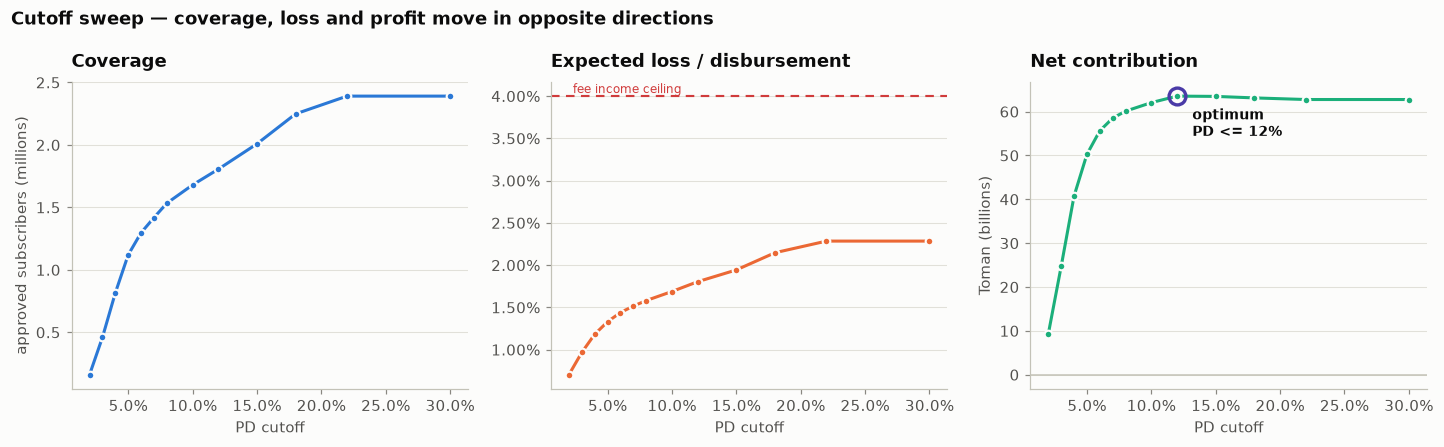

In [27]:
# ---- three measures of different scale -> three panels, never one dual axis
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1))
x = SWEEP["pd_cutoff"]

ax = axes[0]
ax.plot(x, SWEEP["n_approved_real"] / 1e6, marker="o", color=C["s1"],
        markeredgecolor=C["surface"], markeredgewidth=1.4)
style(ax, "Coverage", "PD cutoff", "approved subscribers (millions)")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax = axes[1]
ax.plot(x, SWEEP["el_ratio"], marker="o", color=C["s2"],
        markeredgecolor=C["surface"], markeredgewidth=1.4)
ax.axhline(CONFIG["fee_rate_total"], color=C["critical"], lw=1.4, ls=(0, (4, 3)))
ax.text(x.iloc[0], CONFIG["fee_rate_total"], " fee income ceiling", fontsize=8,
        color=C["critical"], va="bottom")
ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.xaxis.set_major_formatter(PercentFormatter(1.0))
style(ax, "Expected loss / disbursement", "PD cutoff")

ax = axes[2]
ax.plot(x, SWEEP["net_real"] / 1e9, marker="o", color=C["s3"],
        markeredgecolor=C["surface"], markeredgewidth=1.4)
ib = int(SWEEP["net_real"].idxmax())
ax.plot([x.iloc[ib]], [SWEEP["net_real"].iloc[ib] / 1e9], "o", ms=11, mfc="none",
        mec=C["s7"], mew=2.2)
ax.annotate(f"optimum\nPD <= {x.iloc[ib]:.0%}", (x.iloc[ib], SWEEP["net_real"].iloc[ib] / 1e9),
            xytext=(10, -26), textcoords="offset points", fontsize=9, color=C["ink"],
            fontweight="600")
ax.axhline(0, color=C["axis"], lw=1.0)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
style(ax, "Net contribution", "PD cutoff", "Toman (billions)")
fig.suptitle("Cutoff sweep — coverage, loss and profit move in opposite directions",
             x=0.009, ha="left", fontsize=12, fontweight="600", color=C["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.94])
save(fig, "07_cutoff_sweep.png"); plt.show()

## ۱۴. MCDM — انتخاب سیاست نهایی

### چرا اینجا MCDM درست است (و در جای مدل ریسک غلط)
بخش ۱۳ فقط **سود** را حداکثر کرد. ولی کمیتهٔ محصول هم‌زمان چند چیز متضاد می‌خواهد:
پوشش بیشتر، نکول کمتر، حجم تسهیلات بیشتر، تمرکز ریسک کمتر. اینها را نمی‌توان با یک عدد
جمع زد مگر وزن‌گذاری صریح شود — و این **تعریف مسئلهٔ MCDM** است.

### هفت معیار
| معیار | جهت | چرا در لیست است |
|---|---|---|
| تعداد تأییدشده | بیشتر بهتر | دغدغهٔ اصلی: جامعهٔ ۶ میلیونی کم است |
| حجم تسهیلات | بیشتر بهتر | رشد ARPU و درآمد |
| PD وزنی | کمتر بهتر | کیفیت پرتفوی |
| نسبت زیان به تسهیلات | کمتر بهتر | اصلی‌ترین قید ریسک |
| سود خالص | بیشتر بهتر | توجیه مالی |
| بازده روی تسهیلات | بیشتر بهتر | کارایی سرمایه، مستقل از حجم |
| تمرکز در رتبه‌های ضعیف | کمتر بهتر | ریسک دنبالهٔ توزیع |

### چرا سه روش، نه یکی
- **وزن آنتروپی** — وزن از پراکندگی خودِ داده؛ عاری از قضاوت، ولی کور به اولویت کسب‌وکار
- **AHP** — وزن از قضاوت خبره، با سنجش ناسازگاری ($CR < 0.1$)
- **TOPSIS** (نزدیکی به آرمان) و **VIKOR** (راه‌حل سازشی) و **SAW** — سه رتبه‌بندی

اگر سه روش **یک سناریو را بالا ببرند**، انتخاب مستحکم است. اگر نه، سناریوها واقعاً هم‌ارزند و
تصمیم سیاسی است نه فنی. تحلیل حساسیت وزن در پایان همین را کمّی می‌کند.

In [28]:
# ---------------- scenario grid: cutoff x limit generosity ----------------
cut_grid   = [0.04, 0.06, 0.08, 0.10, 0.14]
alpha_grid = [0.85, 1.00, 1.15]
rows = []
for c, a in itertools.product(cut_grid, alpha_grid):
    s = summarise(run_policy(oot, pd_oot, CONFIG, c, alpha_scale=a), CONFIG,
                  f"PD<={c:.0%} | alpha x{a:.2f}")
    s.update(pd_cutoff=c, alpha_scale=a); rows.append(s)
SC = pd.DataFrame(rows).dropna(subset=["net_real"]).reset_index(drop=True)

CRITERIA = pd.DataFrame([
    ("n_approved_real",        "benefit", "Coverage (subscribers)"),
    ("disbursement_real",      "benefit", "Disbursement volume"),
    ("wavg_pd",                "cost",    "Weighted PD"),
    ("el_ratio",               "cost",    "Loss / disbursement"),
    ("net_real",               "benefit", "Net contribution"),
    ("return_on_disbursement", "benefit", "Return on disbursement"),
    ("concentration_DE",       "cost",    "Concentration in D-E"),
], columns=["criterion", "direction", "label"])

M = SC[CRITERIA["criterion"]].to_numpy(float)
DIRS = CRITERIA["direction"].to_numpy()
print(f"{M.shape[0]} scenarios x {M.shape[1]} criteria")
SC[["scenario", "n_approved_real", "disbursement_real", "wavg_pd", "el_ratio",
    "net_real", "return_on_disbursement", "concentration_DE"]].head(15).style.format(
    {"n_approved_real": "{:,.0f}", "disbursement_real": "{:,.0f}", "wavg_pd": "{:.2%}",
     "el_ratio": "{:.2%}", "net_real": "{:,.0f}", "return_on_disbursement": "{:.2%}",
     "concentration_DE": "{:.1%}"})

15 scenarios x 7 criteria


,scenario,n_approved_real,disbursement_real,wavg_pd,el_ratio,net_real,return_on_disbursement,concentration_DE
0,PD<=4% | alpha x0.85,"814,621","279,238,261,364",2.97%,1.14%,"36,133,148,083",12.94%,0.0%
1,PD<=4% | alpha x1.00,"814,621","306,463,605,263",3.07%,1.18%,"40,727,134,442",13.29%,0.0%
2,PD<=4% | alpha x1.15,"814,621","311,273,690,191",3.09%,1.19%,"41,532,897,326",13.34%,0.0%
3,PD<=6% | alpha x0.85,"1,296,617","397,595,303,230",3.59%,1.38%,"48,437,319,478",12.18%,0.0%
4,PD<=6% | alpha x1.00,"1,296,617","441,070,311,603",3.74%,1.44%,"55,617,967,662",12.61%,0.0%
5,PD<=6% | alpha x1.15,"1,296,617","447,709,676,435",3.76%,1.45%,"56,708,754,391",12.67%,0.0%
6,PD<=8% | alpha x0.85,"1,532,844","443,241,758,971",3.96%,1.52%,"52,071,991,263",11.75%,4.4%
7,PD<=8% | alpha x1.00,"1,533,173","492,365,820,574",4.11%,1.58%,"60,101,834,157",12.21%,5.7%
8,PD<=8% | alpha x1.15,"1,533,173","500,025,107,656",4.13%,1.59%,"61,343,562,873",12.27%,5.9%
9,PD<=10% | alpha x0.85,"1,678,923","466,239,360,646",4.21%,1.62%,"53,324,962,218",11.44%,9.1%


In [29]:
# ============================ MCDM machinery =============================
def minmax_benefit(M, dirs, lo=0.001):
    # orient every column so that larger = better, then scale into (0, 1]
    X = M.astype(float).copy()
    for j, d in enumerate(dirs):
        col = X[:, j]
        rng = col.max() - col.min()
        n = (col - col.min()) / rng if rng > 1e-12 else np.ones_like(col)
        X[:, j] = n if d == "benefit" else 1 - n
    return np.clip(X, lo, 1.0)

def entropy_weights(M, dirs):
    X = minmax_benefit(M, dirs)
    P = X / X.sum(0)
    E = -(P * np.log(P)).sum(0) / np.log(X.shape[0])
    d = 1 - E
    return d / d.sum()

SAATY = np.array([1/9, 1/8, 1/7, 1/6, 1/5, 1/4, 1/3, 1/2, 1, 2, 3, 4, 5, 6, 7, 8, 9])
def ahp_matrix_from_priorities(w):
    R = np.outer(w, 1 / np.asarray(w))
    A = SAATY[np.abs(np.log(R[..., None]) - np.log(SAATY)).argmin(-1)]
    np.fill_diagonal(A, 1.0)
    iu = np.triu_indices_from(A, 1)                     # enforce reciprocity
    A[(iu[1], iu[0])] = 1 / A[iu]
    return A

RI = {1: 0, 2: 0, 3: .58, 4: .90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
def ahp_weights(A):
    vals, vecs = np.linalg.eig(A)
    i = int(np.argmax(vals.real))
    w = np.abs(vecs[:, i].real); w = w / w.sum()
    n = A.shape[0]; lam = vals.real[i]
    CI = (lam - n) / (n - 1)
    return w, lam, CI, (CI / RI[n] if RI[n] else 0.0)

def topsis(M, w, dirs):
    N = M / np.sqrt((M ** 2).sum(0))
    V = N * w
    best  = np.where(dirs == "benefit", V.max(0), V.min(0))
    worst = np.where(dirs == "benefit", V.min(0), V.max(0))
    dp = np.sqrt(((V - best) ** 2).sum(1)); dn = np.sqrt(((V - worst) ** 2).sum(1))
    return dn / (dp + dn)

def vikor(M, w, dirs, v=0.5):
    fs = np.where(dirs == "benefit", M.max(0), M.min(0))
    fm = np.where(dirs == "benefit", M.min(0), M.max(0))
    rng = np.where(np.abs(fs - fm) < 1e-12, 1e-12, fs - fm)
    d = w * (fs - M) / rng
    S, R = d.sum(1), d.max(1)
    def nrm(a): return (a - a.min()) / max(a.max() - a.min(), 1e-12)
    return v * nrm(S) + (1 - v) * nrm(R), S, R      # lower Q is better

def saw(M, w, dirs):
    return (minmax_benefit(M, dirs) * w).sum(1)

# ---- expert priorities (replace with your own committee's judgement) -----
PRIOR = np.array([0.14, 0.07, 0.16, 0.20, 0.26, 0.12, 0.05])
A = ahp_matrix_from_priorities(PRIOR)
w_ahp, lam, CI, CR = ahp_weights(A)
w_ent = entropy_weights(M, DIRS)
w_mix = 0.5 * w_ahp + 0.5 * w_ent
w_mix = w_mix / w_mix.sum()

print(f"AHP: lambda_max = {lam:.4f}   CI = {CI:.4f}   CR = {CR:.4f}  "
      f"-> {'CONSISTENT (CR < 0.10)' if CR < 0.10 else 'INCONSISTENT, revise the matrix'}")
WT = pd.DataFrame({"criterion": CRITERIA["label"], "direction": DIRS,
                   "w_entropy": w_ent, "w_AHP": w_ahp, "w_combined": w_mix})
WT.style.format({"w_entropy": "{:.4f}", "w_AHP": "{:.4f}", "w_combined": "{:.4f}"})

AHP: lambda_max = 7.0630   CI = 0.0105   CR = 0.0080  -> CONSISTENT (CR < 0.10)


,criterion,direction,w_entropy,w_AHP,w_combined
0,Coverage (subscribers),benefit,0.1723,0.1323,0.1523
1,Disbursement volume,benefit,0.1187,0.0649,0.0918
2,Weighted PD,cost,0.1681,0.1478,0.1580
3,Loss / disbursement,cost,0.1681,0.2193,0.1937
4,Net contribution,benefit,0.1035,0.2570,0.1803
5,Return on disbursement,benefit,0.1139,0.1247,0.1193
6,Concentration in D-E,cost,0.1552,0.0539,0.1046


In [30]:
SC["topsis"] = topsis(M, w_mix, DIRS)
q, S_, R_ = vikor(M, w_mix, DIRS)
SC["vikor_Q"] = q
SC["saw"] = saw(M, w_mix, DIRS)
SC["rank_topsis"] = SC["topsis"].rank(ascending=False).astype(int)
SC["rank_vikor"]  = SC["vikor_Q"].rank(ascending=True).astype(int)
SC["rank_saw"]    = SC["saw"].rank(ascending=False).astype(int)
SC["rank_profit"] = SC["net_real"].rank(ascending=False).astype(int)
SC["rank_mean"]   = SC[["rank_topsis", "rank_vikor", "rank_saw"]].mean(1)

rho = pd.DataFrame(index=["topsis", "vikor", "saw", "profit_only"],
                   columns=["topsis", "vikor", "saw", "profit_only"], dtype=float)
cols = {"topsis": "rank_topsis", "vikor": "rank_vikor", "saw": "rank_saw", "profit_only": "rank_profit"}
for a_ in rho.index:
    for b_ in rho.columns:
        rho.loc[a_, b_] = stats.spearmanr(SC[cols[a_]], SC[cols[b_]]).statistic
print("Spearman rank agreement between methods:\n")
print(rho.to_string(float_format=lambda v: f"{v: .3f}"))

WINNER = SC.sort_values("rank_mean").iloc[0]
print(f"\nMCDM consensus winner: {WINNER['scenario']}")
SC.sort_values("rank_mean")[["scenario", "n_approved_real", "wavg_pd", "el_ratio", "net_real",
                             "topsis", "vikor_Q", "saw", "rank_topsis", "rank_vikor",
                             "rank_saw", "rank_mean"]].head(10).style.format(
    {"n_approved_real": "{:,.0f}", "wavg_pd": "{:.2%}", "el_ratio": "{:.2%}",
     "net_real": "{:,.0f}", "topsis": "{:.4f}", "vikor_Q": "{:.4f}", "saw": "{:.4f}",
     "rank_mean": "{:.2f}"})

Spearman rank agreement between methods:

             topsis  vikor    saw  profit_only
topsis        1.000  0.954  0.850       -0.368
vikor         0.954  1.000  0.886       -0.179
saw           0.850  0.886  1.000       -0.243
profit_only  -0.368 -0.179 -0.243        1.000

MCDM consensus winner: PD<=6% | alpha x1.15


,scenario,n_approved_real,wavg_pd,el_ratio,net_real,topsis,vikor_Q,saw,rank_topsis,rank_vikor,rank_saw,rank_mean
5,PD<=6% | alpha x1.15,"1,296,617",3.76%,1.45%,"56,708,754,391",0.7215,0.0000,0.6491,1,1,1,1.00
4,PD<=6% | alpha x1.00,"1,296,617",3.74%,1.44%,"55,617,967,662",0.7193,0.0143,0.6416,2,2,2,2.00
3,PD<=6% | alpha x0.85,"1,296,617",3.59%,1.38%,"48,437,319,478",0.6948,0.1959,0.5878,3,3,7,4.33
8,PD<=8% | alpha x1.15,"1,533,173",4.13%,1.59%,"61,343,562,873",0.6269,0.2164,0.6054,6,4,3,4.33
7,PD<=8% | alpha x1.00,"1,533,173",4.11%,1.58%,"60,101,834,157",0.6300,0.2183,0.5980,5,5,4,4.67
2,PD<=4% | alpha x1.15,"814,621",3.09%,1.19%,"41,532,897,326",0.6122,0.4060,0.5977,7,7,5,6.33
6,PD<=8% | alpha x0.85,"1,532,844",3.96%,1.52%,"52,071,991,263",0.6438,0.2514,0.5449,4,6,10,6.67
1,PD<=4% | alpha x1.00,"814,621",3.07%,1.18%,"40,727,134,442",0.6099,0.4164,0.5923,8,8,6,7.33
0,PD<=4% | alpha x0.85,"814,621",2.97%,1.14%,"36,133,148,083",0.5961,0.6162,0.5566,9,12,8,9.67
10,PD<=10% | alpha x1.00,"1,679,581",4.38%,1.69%,"62,046,949,085",0.4972,0.4492,0.5447,11,9,11,10.33


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


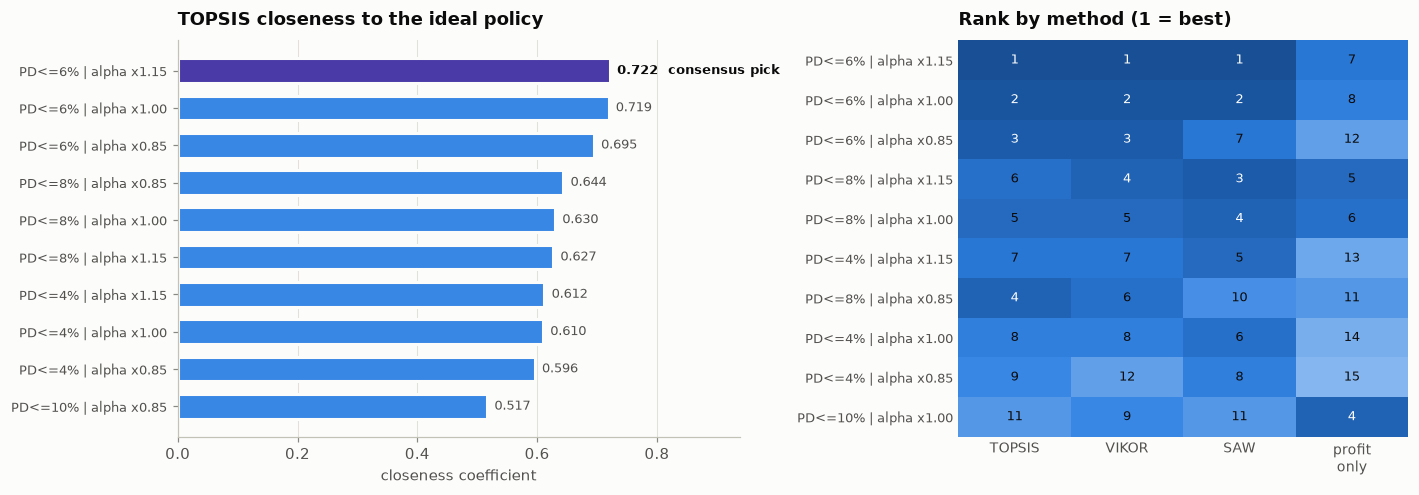

In [31]:
# ---- MCDM results: closeness ranking + cross-method rank agreement
top10 = SC.sort_values("topsis", ascending=False).head(10).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6),
                         gridspec_kw=dict(width_ratios=[1.25, 1]))
ax = axes[0]
isw = (top10["scenario"] == WINNER["scenario"]).to_numpy()
ax.barh(np.arange(len(top10)), top10["topsis"], height=0.66,
        color=np.where(isw, C["s7"], SEQ[3]), edgecolor=C["surface"], linewidth=2)
for i, (v, w_) in enumerate(zip(top10["topsis"], isw)):
    ax.text(v + 0.012, i, f"{v:.3f}" + ("  consensus pick" if w_ else ""),
            va="center", fontsize=8.5, color=C["ink"] if w_ else C["ink2"],
            fontweight="600" if w_ else "normal")
ax.set_yticks(np.arange(len(top10))); ax.set_yticklabels(top10["scenario"], fontsize=8.5)
ax.set_xlim(0, min(1.0, top10["topsis"].max() * 1.30))
style(ax, "TOPSIS closeness to the ideal policy", "closeness coefficient", grid="x")

ax = axes[1]
rk = SC.sort_values("rank_mean").head(10)[["rank_topsis", "rank_vikor", "rank_saw", "rank_profit"]]
im = ax.imshow(rk.to_numpy(), cmap=mpl.colors.LinearSegmentedColormap.from_list("seq", SEQ[::-1]),
               aspect="auto")
for i in range(rk.shape[0]):
    for j in range(rk.shape[1]):
        v = rk.to_numpy()[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5,
                color="#ffffff" if v <= 4 else C["ink"])
ax.set_xticks(range(4)); ax.set_xticklabels(["TOPSIS", "VIKOR", "SAW", "profit\nonly"], fontsize=9)
ax.set_yticks(range(len(rk)))
ax.set_yticklabels(SC.sort_values("rank_mean").head(10)["scenario"], fontsize=8.5)
ax.set_title("Rank by method (1 = best)")
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
save(fig, "08_mcdm.png"); plt.show()

Weight-sensitivity over 500 perturbed weight vectors:

            scenario  median_rank  p10   p90  pct_top3
PD<=6% | alpha x1.15         1.00 1.00  3.00      0.95
PD<=6% | alpha x1.00         2.00 2.00  4.00      0.89
PD<=6% | alpha x0.85         3.00 3.00  6.00      0.76
PD<=8% | alpha x1.00         5.00 3.00  8.00      0.12
PD<=8% | alpha x0.85         6.00 4.00  7.00      0.05
PD<=8% | alpha x1.15         6.00 3.00  9.00      0.19
PD<=4% | alpha x1.15         7.00 4.00 13.00      0.01
PD<=4% | alpha x1.00         8.00 5.00 14.00      0.01

The consensus pick 'PD<=6% | alpha x1.15' lands in the top 3 in 95% of draws.


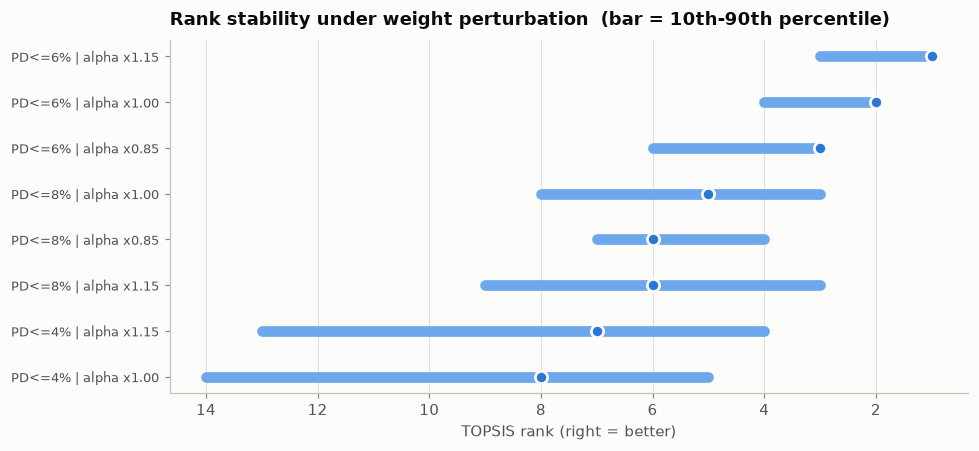

In [32]:
# ---- weight sensitivity: is the winner robust to the weights we guessed?
rng = np.random.default_rng(CONFIG["seed"])
DRAWS = 500
rank_draws = np.zeros((DRAWS, len(SC)), int)
for i in range(DRAWS):
    wd = rng.dirichlet(w_mix * 60)                    # concentrated around w_mix
    sc = topsis(M, wd, DIRS)
    rank_draws[i] = (-sc).argsort().argsort() + 1
SENS = pd.DataFrame(dict(
    scenario=SC["scenario"],
    median_rank=np.median(rank_draws, 0),
    p10=np.percentile(rank_draws, 10, axis=0),
    p90=np.percentile(rank_draws, 90, axis=0),
    pct_top3=(rank_draws <= 3).mean(0),
)).sort_values("median_rank")
print(f"Weight-sensitivity over {DRAWS} perturbed weight vectors:\n")
print(SENS.head(8).to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print(f"\nThe consensus pick '{WINNER['scenario']}' lands in the top 3 in "
      f"{SENS.loc[SENS.scenario == WINNER['scenario'], 'pct_top3'].iloc[0]:.0%} of draws.")

fig, ax = plt.subplots(figsize=(9.0, 4.2))
s8 = SENS.head(8).iloc[::-1]
yy = np.arange(len(s8))
ax.hlines(yy, s8["p10"], s8["p90"], color=SEQ[1], lw=7, capstyle="round")
ax.plot(s8["median_rank"], yy, "o", color=C["s1"], ms=8,
        markeredgecolor=C["surface"], markeredgewidth=1.8, zorder=3)
ax.set_yticks(yy); ax.set_yticklabels(s8["scenario"], fontsize=8.5)
ax.invert_xaxis()
style(ax, "Rank stability under weight perturbation  (bar = 10th-90th percentile)",
      "TOPSIS rank (right = better)", grid="x")
save(fig, "09_weight_sensitivity.png"); plt.show()

## ۱۵. نتایج نهایی

سیاست برندهٔ MCDM اجرا می‌شود و سه خروجی تولید می‌کند:
1. **کارت سیاست** — اعداد سرتیتر برای کمیته
2. **جدول رتبه‌ها** — جوابِ «هر دسته چقدر وام»
3. **نردبان رشد** — جوابِ «چقدر می‌توانیم بدهیم» در افق ۱۲ ماه، نه فقط امروز

In [33]:
WIN_CUT, WIN_ALPHA = float(WINNER["pd_cutoff"]), float(WINNER["alpha_scale"])
final = run_policy(oot, pd_oot, CONFIG, WIN_CUT, alpha_scale=WIN_ALPHA)
appr  = final.loc[final["approve"]].copy()
S_    = POLICY_SCALE

card = {
  "policy": WINNER["scenario"],
  "eligible_after_gates":        int(ELIGIBLE_REAL),
  "scored_rows_OOT":             int(len(final)),
  "approved_subscribers":        int(len(appr) * S_),
  "approval_rate_of_eligible":   len(appr) / len(final),
  "total_disbursement_toman":    float(appr["limit"].sum() * S_),
  "avg_limit_toman":             float(appr["limit"].mean()),
  "median_limit_toman":          float(appr["limit"].median()),
  "avg_installment_toman":       float(appr["installment"].mean()),
  "avg_expected_bill_toman":     float(appr["expected_bill"].mean()),
  "bill_uplift_pct":             float(appr["installment"].mean() / appr["expected_bill"].mean()),
  "weighted_PD":                 float(np.average(appr["pd_adj"], weights=appr["limit"])),
  "realised_bad_rate_on_proxy":  float(appr["y"].mean()),
  "expected_loss_toman":         float(appr["el"].sum() * S_),
  "expected_loss_ratio":         float(appr["el"].sum() / appr["limit"].sum()),
  "net_contribution_toman":      float(appr["net"].sum() * S_),
  "return_on_disbursement":      float(appr["net"].sum() / appr["limit"].sum()),
  "net_per_loan_toman":          float(appr["net"].mean()),
  "champion_gini_OOT":           float(2 * roc_auc_score(yoot, p_oot) - 1),
  "champion_KS_OOT":             float(metrics(yoot, p_oot)["ks"]),
}
print("=" * 72); print("  POLICY CARD".ljust(72)); print("=" * 72)
for k, v in card.items():
    if isinstance(v, float) and abs(v) < 2:  print(f"  {k:<30} {v:>18.2%}")
    elif isinstance(v, float):               print(f"  {k:<30} {v:>18,.0f}")
    else:                                    print(f"  {k:<30} {str(v):>18}")
print("=" * 72)
json.dump(card, open(f"{OUT_DIR}/policy_card.json", "w"), indent=2, ensure_ascii=False)

  POLICY CARD                                                           
  policy                         PD<=6% | alpha x1.15
  eligible_after_gates                      3300600
  scored_rows_OOT                             10032
  approved_subscribers                      1296617
  approval_rate_of_eligible                  39.28%
  total_disbursement_toman          447,709,676,435
  avg_limit_toman                           345,291
  median_limit_toman                        320,000
  avg_installment_toman                      89,776
  avg_expected_bill_toman                   159,818
  bill_uplift_pct                            56.17%
  weighted_PD                                 3.76%
  realised_bad_rate_on_proxy                  3.48%
  expected_loss_toman                 6,481,730,781
  expected_loss_ratio                         1.45%
  net_contribution_toman             56,708,754,391
  return_on_disbursement                     12.67%
  net_per_loan_toman                     

In [34]:
# ---- the answer to "which tier gets how much" ------------------------------
TIERS = (appr.groupby("grade")
         .agg(subscribers=("grade", "size"),
              mean_pd=("pd_adj", "mean"),
              observed_bad=("y", "mean"),
              mean_bill=("expected_bill", "mean"),
              mean_proven_capacity=("proven_capacity", "mean"),
              limit_p25=("limit", lambda s: s.quantile(.25)),
              limit_median=("limit", "median"),
              limit_p75=("limit", lambda s: s.quantile(.75)),
              mean_installment=("installment", "mean"),
              el_ratio=("el", "sum"))
         .reindex([g for g in GRADE_POLICY["grade"] if g in appr["grade"].unique()]))
TIERS["el_ratio"] = TIERS["el_ratio"] / appr.groupby("grade")["limit"].sum()
TIERS["subscribers_real"] = (TIERS["subscribers"] * S_).astype(np.int64)
TIERS["limit_x_bill"] = TIERS["limit_median"] / TIERS["mean_bill"]
TIERS["installment_pct_of_bill"] = TIERS["mean_installment"] / TIERS["mean_bill"]
TIERS = TIERS.join(GRADE_POLICY.set_index("grade")[["alpha", "arpu_mult", "abs_cap"]])
TIERS.to_csv(f"{OUT_DIR}/final_tier_table.csv")
TIERS[["subscribers_real", "mean_pd", "observed_bad", "mean_bill", "mean_proven_capacity",
       "limit_p25", "limit_median", "limit_p75", "limit_x_bill",
       "mean_installment", "installment_pct_of_bill", "el_ratio"]].style.format(
    {"subscribers_real": "{:,.0f}", "mean_pd": "{:.2%}", "observed_bad": "{:.2%}",
     "mean_bill": "{:,.0f}", "mean_proven_capacity": "{:,.0f}", "limit_p25": "{:,.0f}",
     "limit_median": "{:,.0f}", "limit_p75": "{:,.0f}", "limit_x_bill": "{:.2f}x",
     "mean_installment": "{:,.0f}", "installment_pct_of_bill": "{:.0%}", "el_ratio": "{:.2%}"})

,subscribers_real,mean_pd,observed_bad,mean_bill,mean_proven_capacity,limit_p25,limit_median,limit_p75,limit_x_bill,mean_installment,installment_pct_of_bill,el_ratio
grade,,,,,,,,,,,,
A,"107,914",1.67%,2.13%,"159,596","247,695","270,000","445,000","600,000",2.79x,"111,760",70%,0.64%
B,"621,823",3.24%,3.92%,"155,712","227,823","240,000","370,000","590,000",2.38x,"100,247",64%,1.25%
C,"566,221",5.12%,3.25%,"164,403","224,929","170,000","260,000","410,000",1.58x,"74,132",45%,1.98%
D,658,7.20%,0.00%,"129,817","131,576","185,000","190,000","195,000",1.46x,"49,400",38%,2.77%


Graduation path for a grade-C subscriber on a 130k Toman bill:

 cycle  proven_capacity   limit  installment  total_bill
     1          162,500 260,000       67,600     197,600
     2          197,600 260,000       67,600     197,600
     3          197,600 260,000       67,600     197,600
     4          197,600 260,000       67,600     197,600

limit grows 1.00x over 4 settled cycles - with no model change and no committee.


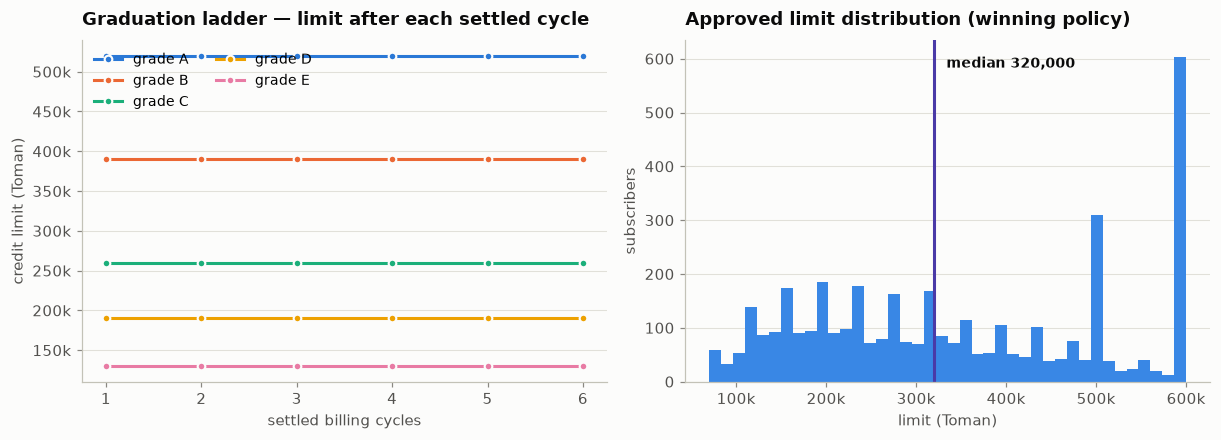

In [35]:
# ---- graduation ladder: the limit a good payer earns over 4 cycles --------
def graduation_path(bill, cycles=4, cfg=CONFIG, grade="C", alpha_scale=1.0):
    pol = GRADE_POLICY.set_index("grade").loc[grade]
    P = bill * 1.25                                  # starting proven capacity
    n, f = cfg["n_installments"], cfg["fee_rate_total"]
    out = []
    for c in range(1, cycles + 1):
        L = min(max(pol["alpha"] * alpha_scale * P - bill, 0) * n / (1 + f),
                pol["arpu_mult"] * bill, cfg["sim_haircut"] * cfg["sim_value_toman"],
                pol["abs_cap"])
        L = np.floor(L / 10_000) * 10_000
        inst = L * (1 + f) / n
        out.append(dict(cycle=c, proven_capacity=P, limit=L, installment=inst,
                        total_bill=bill + inst))
        P = max(P, bill + inst)                      # paid on time -> capacity proven
    return pd.DataFrame(out)

LAD = graduation_path(130_000, cycles=4, grade="C")
print("Graduation path for a grade-C subscriber on a 130k Toman bill:\n")
print(LAD.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))
print(f"\nlimit grows {LAD['limit'].iloc[-1]/max(LAD['limit'].iloc[0],1):.2f}x over "
      f"{len(LAD)} settled cycles - with no model change and no committee.")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.1))
ax = axes[0]
for g, col in zip(["A", "B", "C", "D", "E"], [C["s1"], C["s2"], C["s3"], C["s4"], C["s5"]]):
    p = graduation_path(130_000, 6, grade=g)
    ax.plot(p["cycle"], p["limit"], marker="o", color=col, label=f"grade {g}",
            markeredgecolor=C["surface"], markeredgewidth=1.4)
ax.yaxis.set_major_formatter(TOMAN_FMT)
style(ax, "Graduation ladder — limit after each settled cycle",
      "settled billing cycles", "credit limit (Toman)")
ax.legend(loc="upper left", ncol=2)

ax = axes[1]
ax.hist(appr["limit"], bins=40, color=SEQ[3], lw=0)
ax.axvline(appr["limit"].median(), color=C["s7"], lw=2.0)
ax.annotate(f"median {appr['limit'].median():,.0f}", (appr["limit"].median(), ax.get_ylim()[1] * .92),
            xytext=(8, 0), textcoords="offset points", fontsize=9, color=C["ink"], fontweight="600")
ax.xaxis.set_major_formatter(TOMAN_FMT); ax.yaxis.set_major_formatter(TOMAN_FMT)
style(ax, "Approved limit distribution (winning policy)", "limit (Toman)", "subscribers")
save(fig, "10_ladder_and_limits.png"); plt.show()

In [36]:
# ---- exports -------------------------------------------------------------
decision = pd.concat([
    oot[["subscriber_id", "obs_cohort", "tenure_months", "expected_bill",
         "proven_capacity", "n_suspensions_10m", "dtp_mean", "goodpay_v1", "goodpay_v2"]].reset_index(drop=True),
    pd.DataFrame(dict(score=score_of(Xoot).to_numpy())),
    final[["grade", "pd_base", "pd_adj", "shock", "limit", "installment",
           "binding", "approve", "el", "net"]],
], axis=1)
decision.to_csv(f"{OUT_DIR}/decision_file_sample.csv", index=False)
SWEEP.to_csv(f"{OUT_DIR}/cutoff_sweep.csv", index=False)
SC.to_csv(f"{OUT_DIR}/mcdm_scenarios.csv", index=False)
REPORT.to_csv(f"{OUT_DIR}/model_performance.csv", index=False)
IV.to_csv(f"{OUT_DIR}/information_value.csv", index=False)
WF.to_csv(f"{OUT_DIR}/eligibility_waterfall.csv", index=False)

def as_table(df, index=False):
    # markdown if tabulate is installed, plain text otherwise - the report must never fail
    try:
        return df.to_markdown(index=index, floatfmt=",.4f")
    except ImportError:
        return "```\n" + df.to_string(index=index) + "\n```"

with open(f"{OUT_DIR}/model_report.md", "w", encoding="utf-8") as fh:
    fh.write("# Telco credit scorecard - run report\n\n## Performance\n\n")
    fh.write(as_table(REPORT))
    fh.write("\n\n## Policy card\n\n")
    fh.write(as_table(pd.Series(card).to_frame("value"), index=True))
    fh.write("\n\n## Tier table\n\n")
    fh.write(as_table(TIERS.reset_index()))
    fh.write("\n\n## MCDM ranking\n\n")
    fh.write(as_table(SC.sort_values("rank_mean")
                      [["scenario", "topsis", "vikor_Q", "saw", "rank_mean"]].head(10)))

print("written to", OUT_DIR, "->")
for f in sorted(os.listdir(OUT_DIR)): print("   ", f)
print(f"\ndecision file: {len(decision):,} rows, {decision['approve'].sum():,} approved")
decision.head(6)

written to outputs ->
    01_eligibility_waterfall.png
    02_information_value.png
    03_bad_rate_by_decile.png
    04_roc_ks.png
    05_calibration_scores.png
    06_grades.png
    07_cutoff_sweep.png
    08_mcdm.png
    09_weight_sensitivity.png
    10_ladder_and_limits.png
    cutoff_sweep.csv
    decision_file_sample.csv
    eligibility_waterfall.csv
    final_tier_table.csv
    grade_table.csv
    information_value.csv
    mcdm_scenarios.csv
    model_performance.csv
    model_report.md
    policy_card.json
    scorecard_points.csv

decision file: 10,032 rows, 3,941 approved


,subscriber_id,obs_cohort,tenure_months,expected_bill,proven_capacity,n_suspensions_10m,dtp_mean,goodpay_v1,goodpay_v2,score,grade,pd_base,pd_adj,shock,limit,installment,binding,approve,el,net
0,S00000001,2025-09,72,"389,510.5177","576,263.3343",2,19.4813,50.3012,59.9599,456.3864,G,0.3835,0.3835,0.6759,0.0000,0.0000,affordability,False,0.0000,"-15,000.0000"
1,S00000010,2025-09,75,"257,881.9533","360,341.1266",0,2.7767,100.0000,98.5565,636.2860,B,0.0257,0.0279,1.1486,"600,000.0000","156,000.0000",sim_collateral,True,"6,435.6054","89,314.3946"
2,S00000019,2025-09,84,"102,674.8989","153,513.0227",0,13.8560,100.0000,85.6895,540.3864,E,0.1246,0.1246,0.8382,"100,000.0000","26,000.0000",size_vs_bill,False,"4,796.0318","-1,337.6985"
3,S00000020,2025-09,45,"520,122.6919","707,491.5660",0,3.3955,100.0000,93.0119,643.6216,B,0.0227,0.0227,0.9557,"600,000.0000","156,000.0000",sim_collateral,True,"5,241.4597","90,508.5403"
4,S00000022,2025-09,112,"50,937.9348","140,282.7980",0,2.6508,100.0000,100.0000,647.2098,B,0.0213,0.0213,0.6411,"150,000.0000","39,000.0000",size_vs_bill,True,"1,232.0454","11,455.4546"
5,S00000028,2025-09,84,"431,603.7506","476,207.6924",0,3.2492,100.0000,100.0000,645.8445,B,0.0218,0.0248,1.2339,"600,000.0000","156,000.0000",sim_collateral,True,"5,720.7169","90,029.2831"


## ۱۶. چک‌لیست قبل از اجرای واقعی

### الف) پایداری: PSI
$$\text{PSI} = \sum_b (A_b - E_b)\ln\frac{A_b}{E_b}$$
< ۰٫۱ پایدار · ۰٫۱–۰٫۲۵ هشدار · > ۰٫۲۵ **مدل را بازآموزی کنید**.
ماهانه روی امتیاز و روی هر ویژگی حساب شود.

### ب) سلول کنترل تصادفی — بدون این، مدل هرگز بهتر نمی‌شود
مدل فقط روی کسانی برچسب می‌گیرد که **تأیید شده‌اند**. اگر هر رد شدنی برای همیشه رد بماند،
هیچ‌وقت نمی‌فهمید مرز تصمیم کجاست؛ این **سوگیری انتخاب** است و به آن
*reject inference* می‌گویند. تنها راه حلِ تمیز:

> **۲–۳٪ از متقاضیانِ ردشده را تصادفی تأیید کنید** (با سقف کوچک، به‌عنوان هزینهٔ یادگیری).
> این گروه تنها نمونهٔ بی‌سوگیری شماست و منحنی پاسخِ «سقف → نکول» را می‌سازد.

هزینه‌اش را از اول در بودجه بگذارید: زیان مورد انتظار این سلول × حجمش. ارزشش را دارد.

### ج) آزمایش سقف (champion/challenger)
رابطهٔ سقف و نکول را **مدل یاد نمی‌دهد، آزمایش یاد می‌دهد**. از روز اول چند سلول سقف موازی
روی مشترکین هم‌رتبه اجرا کنید (مثلاً $\alpha \in \{0.85, 1.0, 1.15\}$).

### د) پایش پس از اجرا
| سنجه | دورهٔ گزارش | زنگ خطر |
|---|---|---|
| منحنی vintage به تفکیک رتبه | ماهانه | انحراف از کوهورت قبلی |
| ماتریس roll-rate (۰→۳۰→۶۰→۹۰) | ماهانه | تشدید انتقال به سمت راست |
| PSI امتیاز و ویژگی‌ها | ماهانه | > ۰٫۲۵ |
| نرخ استفاده از سقف | ماهانه | جهش ناگهانی = سیگنال فشار نقدینگی |
| نسبت زیان به کارمزد | ماهانه | > ۱ یعنی قیمت‌گذاری غلط |
| Gini روی کوهورت بالغ‌شده | فصلی | افت > ۰٫۰۵ |

### ه) عدالت
`gender` و `age` از مدل خارج‌اند، ولی **اثر نامتناسب غیرمستقیم** ممکن است. قاعدهٔ ۸۰٪:
نسبت نرخ تأیید گروه ضعیف‌تر به قوی‌تر زیر ۰٫۸ → بررسی کنید کدام ویژگی آن را حمل می‌کند.

### و) ترتیب درست کارها
۱. ساختار حقوقی با بانک/لیزینگ شریک، امکان تعلیق سرویس بابت بدهی اعتباری، و امکان گزارش به
سامانهٔ اعتبارسنجی — **اگر این سه قفل نشود، بقیه بی‌فایده است**
۲. پایلوت ۳ ماهه، ۳۰–۵۰ هزار مشترک، رتبه‌های بالا، فقط شارژ و بسته، سقف کوچک، با گروه کنترل
۳. بازآموزی روی **برچسب واقعی وام** (نه proxy)، برازش مجدد $\kappa$، LGD و EAD از دادهٔ وصول خودتان
۴. گسترش به رتبه‌های پایین‌تر و دسته‌های خرج بیشتر

In [37]:
def psi(expected, actual, bins=10):
    e_ = pd.Series(expected).dropna(); a_ = pd.Series(actual).dropna()
    edges = np.unique(np.nanquantile(e_, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    E = np.clip(np.histogram(e_, edges)[0] / len(e_), 1e-6, None)
    A = np.clip(np.histogram(a_, edges)[0] / len(a_), 1e-6, None)
    return float(((A - E) * np.log(A / E)).sum())

score_dev = score_of(woe_matrix(dev, woe_tr, FEATURES)).to_numpy()
PSI = pd.DataFrame([dict(item="SCORE", psi=psi(score_dev, score_oot))] +
                   [dict(item=f, psi=psi(dev[f], oot[f])) for f in FEATURES])
PSI["verdict"] = pd.cut(PSI["psi"], [-1, .10, .25, 99],
                        labels=["stable", "WATCH", "RETRAIN"])
print("Population Stability Index: development cohorts vs OOT cohort\n")
print(PSI.sort_values("psi", ascending=False).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Population Stability Index: development cohorts vs OOT cohort

               item    psi verdict
  active_days_ratio 0.0014  stable
            dtp_std 0.0013  stable
  distinct_contacts 0.0013  stable
       bureau_score 0.0013  stable
              SCORE 0.0012  stable
      pay_ratio_min 0.0010  stable
          dtp_trend 0.0008  stable
home_cell_stability 0.0008  stable
    n_ontime_months 0.0003  stable
         n_services 0.0002  stable
           pct_late 0.0001  stable


In [38]:
# ---- fairness: 80% rule on attributes deliberately kept out of the model
fair = oot[["gender", "age"]].reset_index(drop=True).join(final[["approve", "pd_adj", "limit"]])
fair["age_band"] = pd.cut(fair["age"], [17, 25, 35, 45, 55, 100],
                          labels=["18-25", "26-35", "36-45", "46-55", "56+"])
for col in ["gender", "age_band"]:
    g = fair.groupby(col, observed=True).agg(n=("approve", "size"), approval=("approve", "mean"),
                                             mean_pd=("pd_adj", "mean"), mean_limit=("limit", "mean"))
    g["ratio_to_best"] = g["approval"] / g["approval"].max()
    g["80pct_rule"] = np.where(g["ratio_to_best"] >= 0.80, "pass", "REVIEW")
    print(f"\n--- disparate impact by {col} ---")
    print(g.to_string(formatters={"n": "{:,.0f}".format, "approval": "{:.1%}".format,
                                  "mean_pd": "{:.2%}".format, "mean_limit": "{:,.0f}".format,
                                  "ratio_to_best": "{:.3f}".format}))


--- disparate impact by gender ---
           n approval mean_pd mean_limit ratio_to_best 80pct_rule
gender                                                           
0      5,058    39.2%  13.59%    187,709         0.997       pass
1      4,974    39.3%  13.67%    187,694         1.000       pass

--- disparate impact by age_band ---
             n approval mean_pd mean_limit ratio_to_best 80pct_rule
age_band                                                           
18-25    1,493    38.7%  13.82%    188,098         0.968       pass
26-35    2,946    38.7%  13.57%    187,770         0.968       pass
36-45    3,415    39.9%  13.59%    188,266         0.998       pass
46-55    1,732    40.0%  13.57%    189,492         1.000       pass
56+        446    37.2%  13.89%    174,641         0.930       pass


---

## خلاصهٔ یک صفحه‌ای

| سؤال شما | جواب این نوت‌بوک |
|---|---|
| **ویژگی‌ها چی باشه؟** | هفت گروه در بخش ۱؛ قوی‌ترین گروه **زمان‌بندی پرداخت** (`dtp_*`) است که امتیاز فعلی شما آن را نمی‌بیند. بخش ۶ با IV ثابتش می‌کند |
| **تارگت چی باشه؟** | بدحسابی رفتاری در **پنجرهٔ نتیجهٔ ۴ ماهه**: $\max(\text{DPD})\ge 60$ یا $\ge 2$ ماه تأخیر. برچسب نکول واقعی ندارید، پس جانشین رفتاری تنها گزینهٔ درست است |
| **مدل؟** | لجستیک روی WOE (champion، قابل دفاع، جدول امتیاز چاپی) + GBM (challenger، سقف قدرت تفکیک) |
| **به کی وام بدهیم؟** | PD زیر نقطهٔ برشِ انتخاب‌شده با MCDM، بعد از دروازه‌های سیاستی بخش ۴ |
| **چقدر؟** | $L=\min$ از چهار قید، با لنگر **ظرفیت اثبات‌شدهٔ پرداخت** — جدول رتبه‌ها در بخش ۱۵ |
| **ریسک نکول؟** | PD کالیبره‌شده + ضریب شوک پرداخت؛ EL و نسبت زیان در بخش‌های ۱۲ و ۱۵ |
| **چند نفر؟** | آبشار بخش ۴ و جدول مقایسهٔ «ریسک‌محور در برابر ARPU‌محور» |
| **MCDM کجا؟** | بخش ۱۴ — انتخاب بین سناریوهای سیاستی با معیارهای متضاد، با سه روش و تحلیل حساسیت وزن |

### سه عددی که باید از دادهٔ خودتان برازش کنید، نه حدس بزنید
1. **LGD و EAD** — از منحنی وصول تاریخی بدهی‌های معوق. این را دارید.
2. **$\kappa$ (حساسیت شوک پرداخت)** — بعد از ۶ ماه وام واقعی.
3. **`opex_per_loan`** — با تیکت خرد، همین عدد مرز سود و زیان است.